In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [2]:
# connect to the local SQLite database
conn = sqlite3.connect(r"c:\Users\akand\Downloads\MIG_Cement_Records.db")
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
print(tables)

# Load tables into DataFrames
operations = pd.read_sql_query("SELECT * FROM Operations", conn)
sites = pd.read_sql_query("SELECT * FROM Sites", conn)
cement = pd.read_sql_query("SELECT * FROM CementTypes", conn)

# Close connection
conn.close()

[('Sites',), ('CementTypes',), ('Operations',)]


In [3]:
# ============================================================
# 1. LOAD ALL TABLES SAFELY, THEN CLOSE CONNECTION
# ============================================================

conn = sqlite3.connect(r"C:\Users\akand\Downloads\MIG_Cement_Records.db")
cursor = conn.cursor()

tables = ["Operations", "Sites", "CementTypes"]

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    print(f"{table} row count:", cursor.fetchone()[0])

operations = pd.read_sql_query("SELECT * FROM Operations", conn)
sites = pd.read_sql_query("SELECT * FROM Sites", conn)
cement = pd.read_sql_query("SELECT * FROM CementTypes", conn)

conn.close()   # SAFE — all cleaning happens in pandas now

Operations row count: 32880
Sites row count: 30
CementTypes row count: 3


In [4]:
# ============================================================
# 2. BASIC STRUCTURAL INFORMATION - 
# (DISSHT) - Describe, Info, Shape, Sample, Head, Tail
# (NUDCD)- Nulls, Unique values, Duplicates, Columns, Dtypes 
# ============================================================

def preview_df(df, table):
    """Professional preview of a dataframe."""
    print(f"\n{'='*60}")
    print(f"[table] {table.upper()}")
    print(f"{'='*60}")

    print("\n[DESCRIBE]")
    print(df.describe())

    print("\n[INFO]")
    print(df.info())

    print("\n[SHAPE]")
    print(df.shape)
    print("\n")

    print("\n[SAMPLE]")
    print(df.sample())

    print("\n[HEAD]")
    print(df.head())

    print("\n[TAIL]")
    print(df.tail())

    print("\n[NULL VALUES]")
    print(df.isna().sum())
    
    print("\n[UNIQUE VALUES]")
    print(df.nunique())

    print("\n[DUPLICATES]")
    print(df.duplicated().sum())

    print("\n[COLUMNS]")
    print(df.columns)

    print("\n[DTYPES]")
    print(df.dtypes)



In [5]:
# Call the function
preview_df(operations, "operations")
preview_df(sites, "sites")
preview_df(cement, "cement")


[table] OPERATIONS

[DESCRIBE]
       planned_pour_tonnes  consumed_tonnes  opening_inventory_tonnes  \
count         32880.000000     32880.000000              32880.000000   
mean             30.697158        23.720475               3066.682205   
std              19.493713        16.846251               5586.029168   
min               0.000000         0.000000                  0.000000   
25%              12.830000        10.710000                  1.280000   
50%              33.455000        19.720000                 50.710000   
75%              47.612500        36.492500               3298.522500   
max              69.980000        69.970000              20646.180000   

       deliveries_tonnes  closing_inventory_tonnes       rain_mm  \
count       32880.000000              32880.000000  32880.000000   
mean           29.293009               3072.254739      5.008120   
std            12.325600               5593.015910      4.997142   
min             0.000000              

In [6]:
# ============================================================
# 3. CONVERT DATE COLUMN
# ============================================================

operations['date'] = pd.to_datetime(operations['date'], errors='coerce')

In [7]:
# ============================================================
# 4. STANDARDISE IDs (site_id, cement_type)
# ============================================================

def clean_id(series):
    return (
        series.astype(str)
              .str.strip()
              .str.upper()
    )

operations['site_id'] = clean_id(operations['site_id'])
operations['cement_type'] = clean_id(operations['cement_type'])

sites['site_id'] = clean_id(sites['site_id'])
cement['cement_type'] = clean_id(cement['cement_type'])

In [9]:
# ============================================================
# 5. check for spelling errors, trailing spaces,
# weird characters, and inconsistent casing.
# ============================================================

def check_categorical(df, col):
    print(f"\n{'='*60}")
    print(f"Checking column: {col}")
    print(f"{'='*60}")

    # Raw unique values
    print("\n[RAW UNIQUE VALUES]")
    print(df[col].unique())

    # Strip whitespace
    stripped = df[col].astype(str).str.strip()
    print("\n[STRIPPED UNIQUE VALUES]")
    print(stripped.unique())

    # Uppercase
    upper = stripped.str.upper()
    print("\n[UPPERCASE UNIQUE VALUES]")
    print(upper.unique())

    # Compare raw vs cleaned
    mismatches = df[col][upper != df[col]]
    print("\n[MISMATCHED VALUES (raw vs cleaned)]")
    print(mismatches.head())

    # Check for hidden characters
    weird = df[col].astype(str).apply(lambda x: repr(x))
    print("\n[VALUES WITH HIDDEN CHARACTERS]")
    print(weird.head())

    print("\nDone.")


In [10]:
# Run checks on all categorical columns
# Operations
check_categorical(operations, "site_id")
check_categorical(operations, "cement_type")

# Sites
check_categorical(sites, "site_id")
check_categorical(sites, "region")
check_categorical(sites, "behavior")

# CementTypes
check_categorical(cement, "cement_type")



Checking column: site_id

[RAW UNIQUE VALUES]
['SITE_001' 'SITE_002' 'SITE_003' 'SITE_004' 'SITE_005' 'SITE_006'
 'SITE_007' 'SITE_008' 'SITE_009' 'SITE_010' 'SITE_011' 'SITE_012'
 'SITE_013' 'SITE_014' 'SITE_015' 'SITE_016' 'SITE_017' 'SITE_018'
 'SITE_019' 'SITE_020' 'SITE_021' 'SITE_022' 'SITE_023' 'SITE_024'
 'SITE_025' 'SITE_026' 'SITE_027' 'SITE_028' 'SITE_029' 'SITE_030']

[STRIPPED UNIQUE VALUES]
['SITE_001' 'SITE_002' 'SITE_003' 'SITE_004' 'SITE_005' 'SITE_006'
 'SITE_007' 'SITE_008' 'SITE_009' 'SITE_010' 'SITE_011' 'SITE_012'
 'SITE_013' 'SITE_014' 'SITE_015' 'SITE_016' 'SITE_017' 'SITE_018'
 'SITE_019' 'SITE_020' 'SITE_021' 'SITE_022' 'SITE_023' 'SITE_024'
 'SITE_025' 'SITE_026' 'SITE_027' 'SITE_028' 'SITE_029' 'SITE_030']

[UPPERCASE UNIQUE VALUES]
['SITE_001' 'SITE_002' 'SITE_003' 'SITE_004' 'SITE_005' 'SITE_006'
 'SITE_007' 'SITE_008' 'SITE_009' 'SITE_010' 'SITE_011' 'SITE_012'
 'SITE_013' 'SITE_014' 'SITE_015' 'SITE_016' 'SITE_017' 'SITE_018'
 'SITE_019' 'SITE_020' 'SIT

In [11]:
# ============================================================
# 6. VALIDATE JOIN KEYS — SITE IDs
# ============================================================

missing_sites = set(operations['site_id']) - set(sites['site_id'])
print("\nMissing site_ids (Operations → Sites):", missing_sites)

if len(missing_sites) == 0:
    print("✔ All site_ids in Operations exist in Sites.")
else:
    print("⚠ Some site_ids do not exist in Sites — investigate before merging.")



Missing site_ids (Operations → Sites): set()
✔ All site_ids in Operations exist in Sites.


In [12]:
# ============================================================
# 7. VALIDATE JOIN KEYS — CEMENT TYPES
# ============================================================

missing_cement = set(operations['cement_type']) - set(cement['cement_type'])
print("\nMissing cement_types (Operations → CementTypes):", missing_cement)

if len(missing_cement) == 0:
    print("✔ All cement_types in Operations exist in CementTypes.")
else:
    print("⚠ Some cement_types do not exist in CementTypes — investigate before merging.")


Missing cement_types (Operations → CementTypes): set()
✔ All cement_types in Operations exist in CementTypes.


In [13]:
# ============================================================
# 8. VALIDATE INVENTORY LOGIC
# ============================================================

operations['expected_closing'] = (
    operations['opening_inventory_tonnes'] +
    operations['deliveries_tonnes'] -
    operations['consumed_tonnes']
)

operations['inventory_match'] = (
    operations['expected_closing'].round(2) ==
    operations['closing_inventory_tonnes'].round(2)
)

inventory_issues = operations[operations['inventory_match'] == False]

print("\nInventory mismatches:", len(inventory_issues))

if len(inventory_issues) == 0:
    print("✔ Inventory logic is consistent across all rows.")
else:
    print("⚠ Inventory mismatches detected — review these rows.")
    print(inventory_issues[['date','site_id','cement_type',
                            'opening_inventory_tonnes','deliveries_tonnes',
                            'consumed_tonnes','closing_inventory_tonnes',
                            'expected_closing']].head())


Inventory mismatches: 7
⚠ Inventory mismatches detected — review these rows.
            date   site_id cement_type  opening_inventory_tonnes  \
1096  2022-01-01  SITE_002       CEM_I                     28.46   
13152 2022-01-01  SITE_013     CEM_III                     24.44   
15344 2022-01-01  SITE_015       CEM_I                     26.95   
25208 2022-01-01  SITE_024      CEM_II                     73.23   
28496 2022-01-01  SITE_027      CEM_II                     62.79   

       deliveries_tonnes  consumed_tonnes  closing_inventory_tonnes  \
1096               12.12            15.70                     24.87   
13152              25.63            50.08                      0.00   
15344              18.36             9.46                     35.86   
25208              36.61            64.29                     45.56   
28496              13.10            12.38                     63.52   

       expected_closing  
1096              24.88  
13152             -0.01  
15344   

In [14]:
##fixing the inventory mismatch. 
# In real construction data, mismatches happen because:
# A delivery was recorded late
# A pour was recorded on the wrong day
# A weighbridge malfunctioned
# Someone typed the wrong number
# Inventory was manually adjusted
# A delivery was missed or duplicated


In [15]:
# Recalculate expected closing
operations['expected_closing'] = (
    operations['opening_inventory_tonnes'] +
    operations['deliveries_tonnes'] -
    operations['consumed_tonnes']
)

# Compare using tolerance
operations['inventory_match'] = np.isclose(
    operations['expected_closing'],
    operations['closing_inventory_tonnes'],
    atol=0.01
)

# Fix mismatches
operations.loc[~operations['inventory_match'], 'closing_inventory_tonnes'] = \
    operations.loc[~operations['inventory_match'], 'expected_closing']

# Recompute match
operations['inventory_match'] = np.isclose(
    operations['expected_closing'],
    operations['closing_inventory_tonnes'],
    atol=0.01
)

# Count mismatches
print("Remaining mismatches:", (~operations['inventory_match']).sum())


Remaining mismatches: 0


In [16]:
# merge the tables using left join site_id 
#merge the tables using left join cement_type
merged = operations.merge(sites, on="site_id", how="left")
merged = merged.merge(cement, on="cement_type", how="left")

In [17]:
# identify redundant columns - duplicates or unnnecessary columns (those with only one unique value)
redundant_columns = [col for col in merged.columns if merged[col].nunique() == 1]
print("Redundant columns:", redundant_columns)

Redundant columns: ['inventory_match']


In [18]:
# drop redundant columns - inventory_match.
merged = merged.drop(columns=["inventory_match"])


In [19]:
# Check for duplicates in the merged DataFrame
# duplicates = merged[merged.duplicated()]
merged.columns


Index(['date', 'site_id', 'cement_type', 'planned_pour_tonnes',
       'consumed_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes',
       'closing_inventory_tonnes', 'rain_mm', 'avg_temp_c', 'silo_capacity_x',
       'expected_closing', 'region', 'silo_capacity_y', 'behavior'],
      dtype='object')

### EDA - EXPLORATORY DATA ANALYSIS


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [21]:
df = merged.copy()
df.head()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity_x,expected_closing,region,silo_capacity_y,behavior
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448,63.85,North,448,aggressive
1,2022-01-02,SITE_001,CEM_I,45.26,45.26,63.85,19.97,38.56,3.23,14.28,448,38.56,North,448,aggressive
2,2022-01-03,SITE_001,CEM_III,38.69,38.69,38.56,47.19,47.06,2.64,6.40,448,47.06,North,448,aggressive
3,2022-01-04,SITE_001,CEM_I,33.16,33.16,47.06,18.74,32.64,8.25,14.23,448,32.64,North,448,aggressive
4,2022-01-05,SITE_001,CEM_III,56.88,47.04,32.64,14.40,0.00,2.69,8.97,448,0.00,North,448,aggressive


###### NOTE Tosin - Silo_capacity_x is from the first table (Operations) 
###### and Silo_capacity_y is from the second table (CementTypes). 
###### You might want to rename them for clarity.


In [22]:
# Renaming columns - silo_capacity_x and silo_capacity_y for clarity and consistency.
# Remove the duplicate silo capacity column from operations
merged = merged.drop(columns=["silo_capacity_x"])

# Rename the silo capacity column from sites
merged = merged.rename(columns={"silo_capacity_y": "silo_capacity"})


In [23]:
# ============================================================
# EDA 1. BASIC STRUCTURAL INFORMATION  
# (DISSHT) - Describe, Info, Shape, Sample, Head, Tail
# (NUDCD)- Nulls, Unique values, Duplicates, Columns, Dtypes 
# ============================================================

def preview_df(df, name):
    """Professional preview of a dataframe."""
    print(f"\n{'='*60}")
    print(f"[TABLE] {name.upper()}")
    print(f"{'='*60}")

    print("\n[DESCRIBE]")
    print(df.describe())

    print("\n[INFO]")
    print(df.info())

    print("\n[SHAPE]")
    print(df.shape)

    print("\n[SAMPLE]")
    print(df.sample())

    print("\n[HEAD]")
    print(df.head())

    print("\n[TAIL]")
    print(df.tail())

    print("\n[NULL VALUES]")
    print(df.isna().sum())
    
    print("\n[UNIQUE VALUES]")
    print(df.nunique())

    print("\n[DUPLICATES]")
    print(df.duplicated().sum())

    print("\n[COLUMNS]")
    print(df.columns)

    print("\n[DTYPES]")
    print(df.dtypes)


In [24]:
preview_df(df, "cleaned merged dataset")


[TABLE] CLEANED MERGED DATASET

[DESCRIBE]
                                date  planned_pour_tonnes  consumed_tonnes  \
count                          32880         32880.000000     32880.000000   
mean   2023-07-02 12:00:00.000000256            30.697158        23.720475   
min              2022-01-01 00:00:00             0.000000         0.000000   
25%              2022-10-01 18:00:00            12.830000        10.710000   
50%              2023-07-02 12:00:00            33.455000        19.720000   
75%              2024-04-01 06:00:00            47.612500        36.492500   
max              2024-12-31 00:00:00            69.980000        69.970000   
std                              NaN            19.493713        16.846251   

       opening_inventory_tonnes  deliveries_tonnes  closing_inventory_tonnes  \
count              32880.000000       32880.000000              32880.000000   
mean                3066.682205          29.293009               3072.254739   
min          

In [25]:
# quick check 
merged.columns

Index(['date', 'site_id', 'cement_type', 'planned_pour_tonnes',
       'consumed_tonnes', 'opening_inventory_tonnes', 'deliveries_tonnes',
       'closing_inventory_tonnes', 'rain_mm', 'avg_temp_c', 'expected_closing',
       'region', 'silo_capacity', 'behavior'],
      dtype='object')

##### TIME SERIES ANALYSIS EDA

The graph/code below is meant to check for seasonality, trends, cyclicity, spikes and quiet periods.  

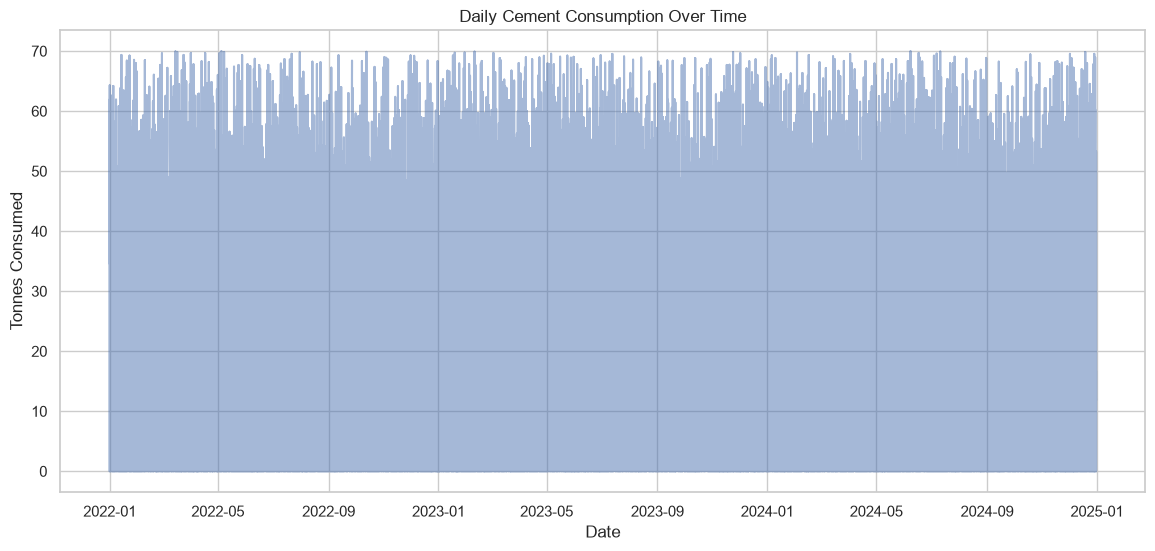

In [26]:
# 1. Start fresh
df = merged.copy()

# 2. Make sure date is a column
df = df.reset_index(drop=True)

# 3. Sort by date
df = df.sort_values("date")

# 4. Set date as index for time‑series work
df = df.set_index("date")

# 5. Plot using df.index
plt.figure(figsize=(14,6))
plt.plot(df.index, df['consumed_tonnes'], alpha=0.5)
plt.title("Daily Cement Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Tonnes Consumed")
plt.show()


##### Insight:There is noise in the daily pattern. Daily data is too noisy to reveal meaningful patterns. Cement consumption varies sharply day‑to‑day, making it impossible to understand seasonality or business cycles at this granularity. This chart tells me one thing: we need to zoom out. 

In [27]:
df.columns

Index(['site_id', 'cement_type', 'planned_pour_tonnes', 'consumed_tonnes',
       'opening_inventory_tonnes', 'deliveries_tonnes',
       'closing_inventory_tonnes', 'rain_mm', 'avg_temp_c', 'expected_closing',
       'region', 'silo_capacity', 'behavior'],
      dtype='object')

####### = - Note Tosin, u had to change the date coloumn into the index so as to be able to play around with the dataset. 

### Monthly Cement Consumption.

C:\Users\akand\AppData\Local\Temp\ipykernel_2692\3190044662.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['consumed_tonnes'].resample('M').sum()


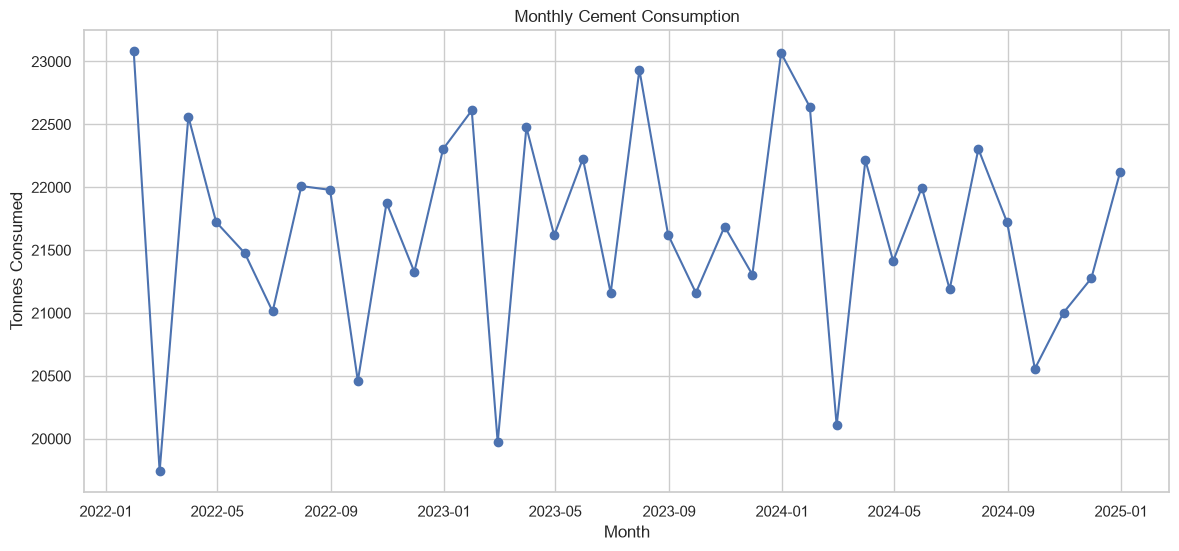

In [28]:
monthly = df['consumed_tonnes'].resample('M').sum()
plt.figure(figsize=(14,6))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Monthly Cement Consumption")
plt.xlabel("Month")
plt.ylabel("Tonnes Consumed")
plt.grid(True)
plt.show()


##### Insight: This smooths out daily noise and shows seasonality. With likely spikes at the begining of the year. The business consistently ramps up at the start of each year, dips mid‑year, and stabilises towards year‑end. This shows the rhythm of the business.

C:\Users\akand\AppData\Local\Temp\ipykernel_2692\1985147188.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df['consumed_tonnes'].resample('Q').sum()


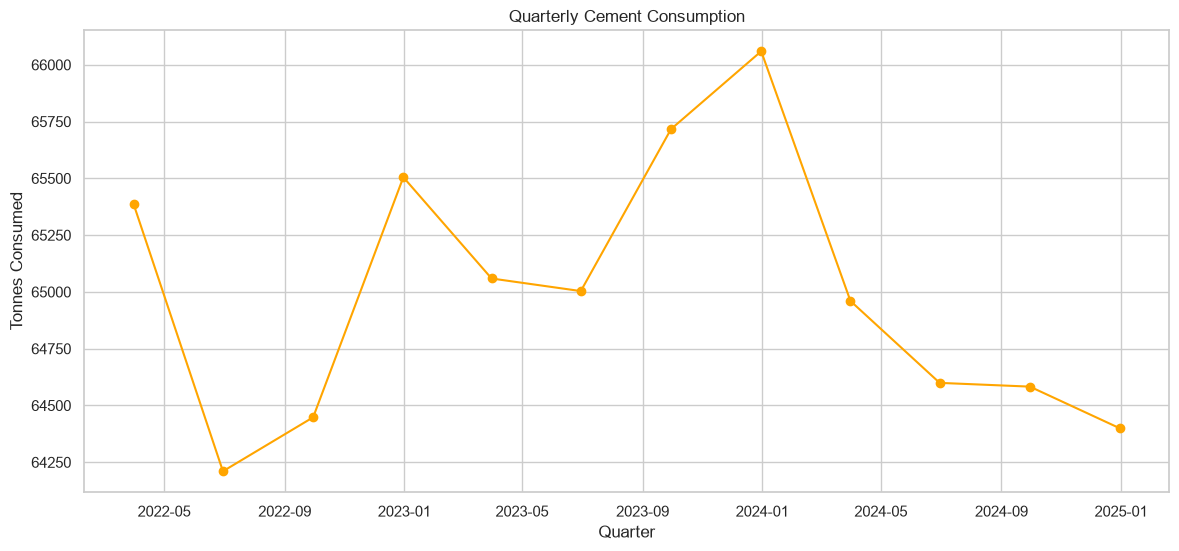

In [29]:
# Quarterly Cement Consumption.

quarterly = df['consumed_tonnes'].resample('Q').sum()
plt.figure(figsize=(14,6))
plt.plot(quarterly.index, quarterly.values, marker='o', color='orange')
plt.title("Quarterly Cement Consumption")
plt.xlabel("Quarter")
plt.ylabel("Tonnes Consumed")
plt.grid(True)
plt.show()

### insight: Quarterly consumption aligns with construction cycles. Q1 is the strongest quarter, indicating project mobilisation and early‑year pour activity. 
### This chart is perfect for management reporting — it shows the business cycle clearly.Perfect for business reporting and strategic planning. This shows the cycle of the business. 

C:\Users\akand\AppData\Local\Temp\ipykernel_2692\570664464.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['consumed_tonnes'].resample('Y').sum()


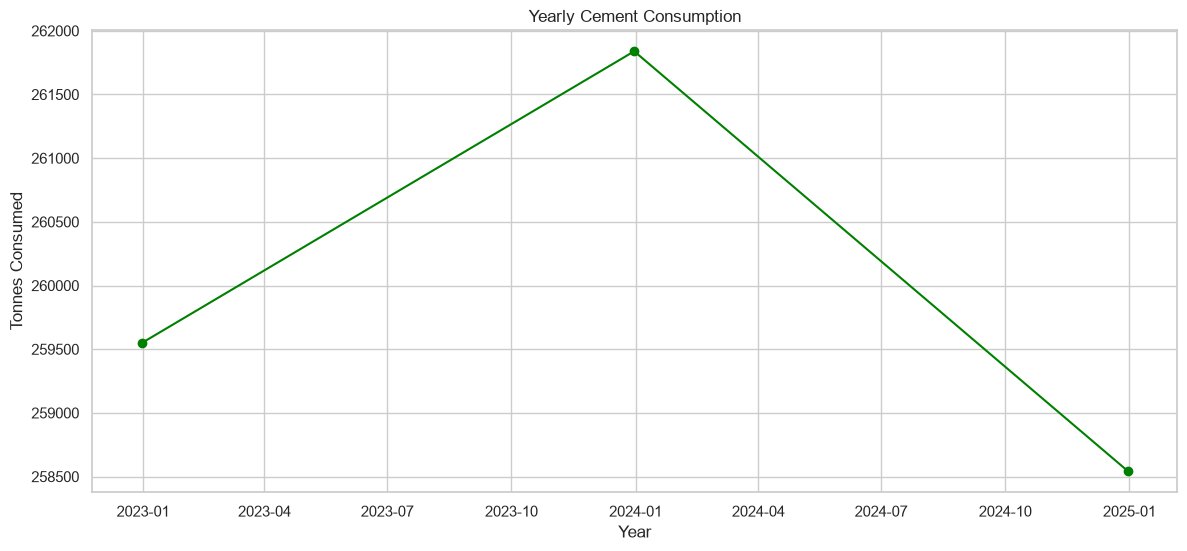

In [30]:
# Yearly Cement Consumption 

yearly = df['consumed_tonnes'].resample('Y').sum()
plt.figure(figsize=(14,6))
plt.plot(yearly.index, yearly.values, marker='o', color='green')
plt.title("Yearly Cement Consumption")
plt.xlabel("Year")
plt.ylabel("Tonnes Consumed")
plt.grid(True)
plt.show()

### Insight: Yearly consumption shows structural growth in 2024. This suggests increased project load, expanded site activity, or improved operational efficiency — it shows the business is growing.

c:\Users\akand\OneDrive\Documents\data journey\Amdari Resources\DS Projects\Ridewise Project\ridewise-venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


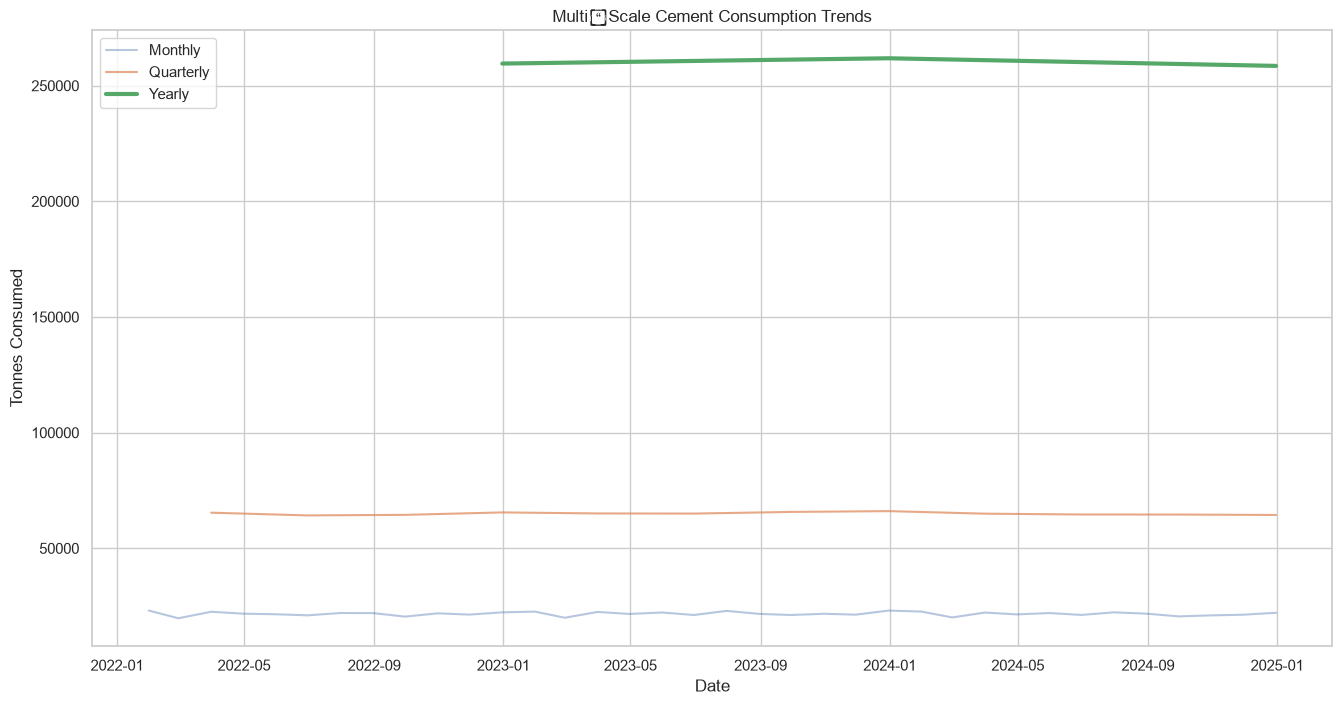

In [31]:
# A multiscalr comparison.

plt.figure(figsize=(16,8))
plt.plot(monthly.index, monthly.values, alpha=0.4, label='Monthly')
plt.plot(quarterly.index, quarterly.values, alpha=0.7, label='Quarterly')
plt.plot(yearly.index, yearly.values, linewidth=3, label='Yearly')

plt.title("Multi‑Scale Cement Consumption Trends")
plt.xlabel("Date")
plt.ylabel("Tonnes Consumed")
plt.legend()
plt.grid(True)
plt.show()  




### Daily noise disappears, Monthly seasonality becomes clear, Quarterly cycles become stable, Yearly growth becomes undeniable
### Insight: This multi‑scale view shows the full story: noise → seasonality → cycles → structural growth. 

##### Daily planned pours

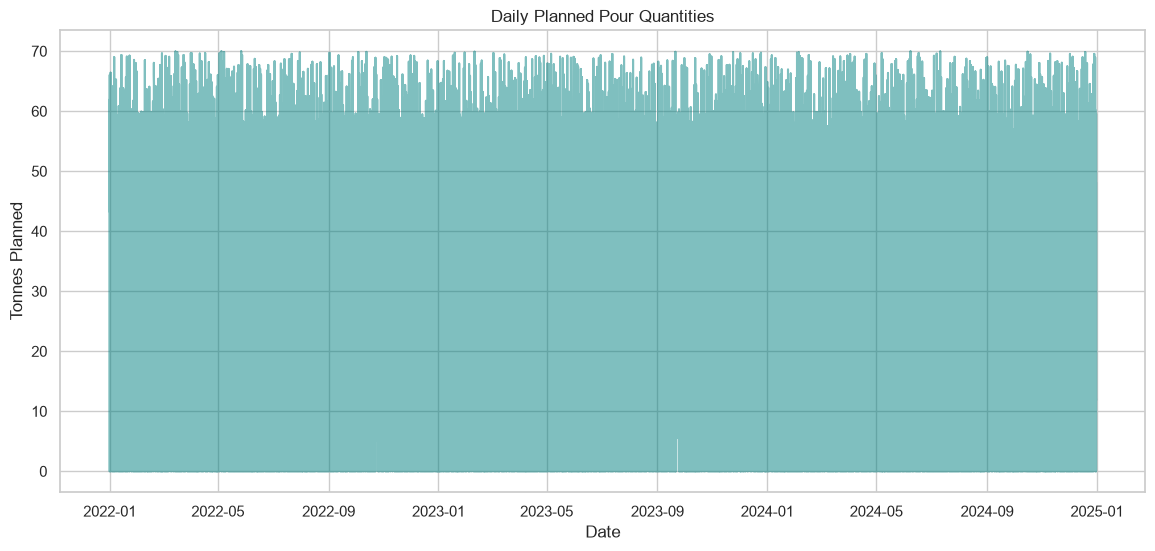

In [32]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['planned_pour_tonnes'], alpha=0.5, color='teal')
plt.title("Daily Planned Pour Quantities")
plt.xlabel("Date")
plt.ylabel("Tonnes Planned")
plt.show()

### Insight: Planned pours mirror actual consumption, confirming operational alignment. This supports forecasting — planned pours can be used as a leading indicator.

C:\Users\akand\AppData\Local\Temp\ipykernel_2692\65223759.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['planned_pour_tonnes'].resample('M').sum()


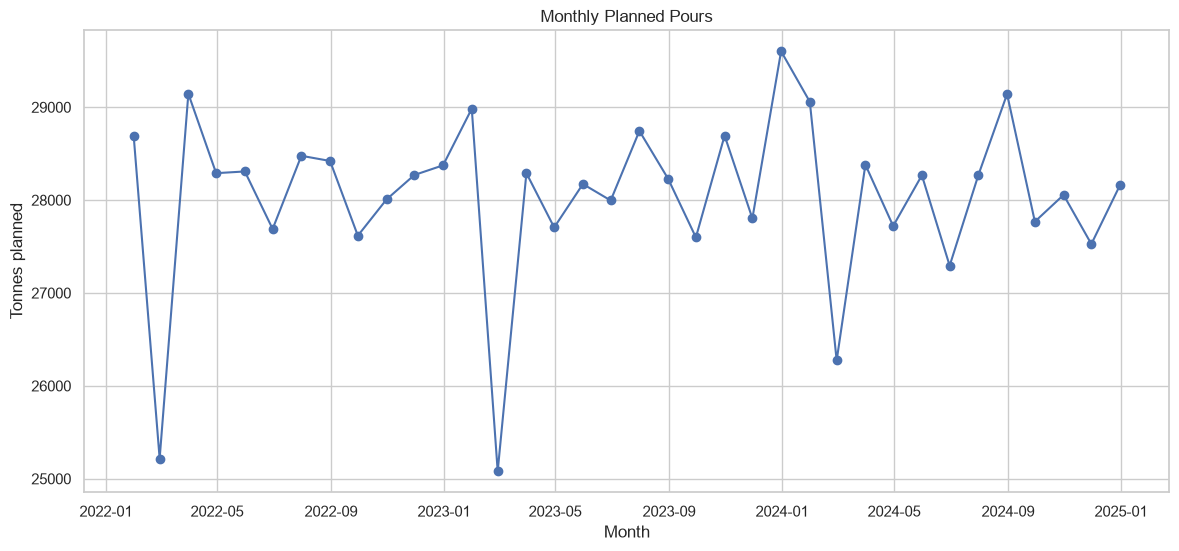

In [33]:
# Monthly planned pours
monthly = df['planned_pour_tonnes'].resample('M').sum()
plt.figure(figsize=(14,6))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Monthly Planned Pours")
plt.xlabel("Month")
plt.ylabel("Tonnes planned")
plt.grid(True)
plt.show()

##### Insight:Planned pours mirror actual consumption, confirming operational alignment.This supports forecasting — planned pours can be used as a leading indicator. 

C:\Users\akand\AppData\Local\Temp\ipykernel_2692\669031263.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['planned_pour_tonnes'].resample('Y').sum()


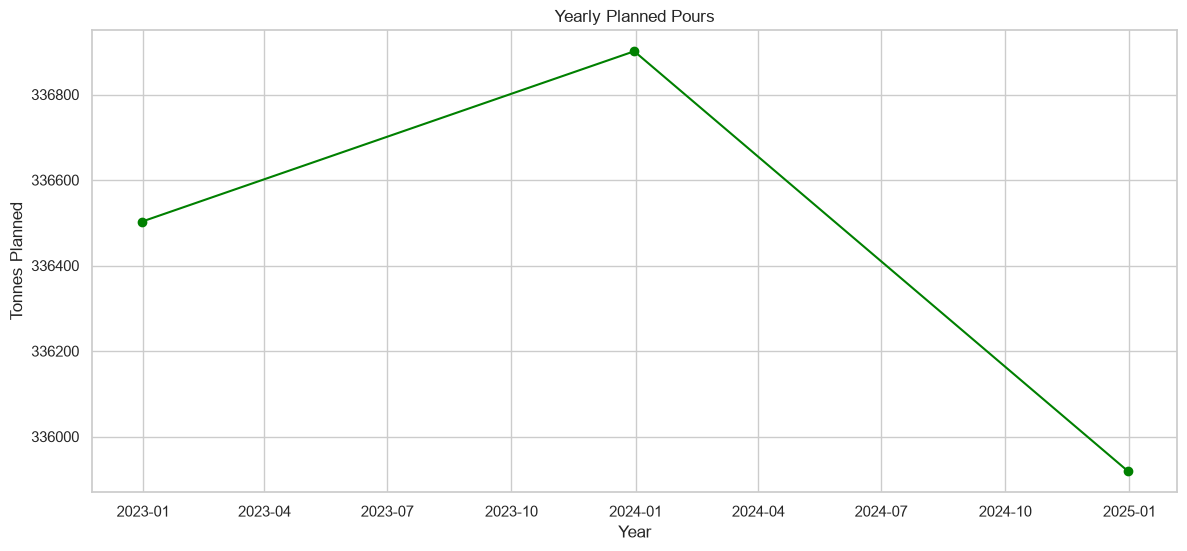

In [34]:
# Yearly planned pours 

yearly = df['planned_pour_tonnes'].resample('Y').sum()
plt.figure(figsize=(14,6))
plt.plot(yearly.index, yearly.values, marker='o', color='green')
plt.title("Yearly Planned Pours")
plt.xlabel("Year")
plt.ylabel("Tonnes Planned")
plt.grid(True)
plt.show()

##### Year 2024, had the higest number of planned pour

#### Site‑Level EDA

##### Top 15 Sites.

In [35]:
site_consumption = df.groupby("site_id")["consumed_tonnes"].sum().sort_values(ascending=False)
site_consumption.head(15)

site_id
SITE_025    33604.06
SITE_010    33579.76
SITE_018    33348.09
SITE_001    33056.40
SITE_021    33009.68
SITE_005    32935.68
SITE_022    32934.03
SITE_008    32689.50
SITE_007    32607.65
SITE_011    32587.01
SITE_020    32585.67
SITE_017    32530.14
SITE_003    32520.09
SITE_030    32459.18
SITE_024    29919.14
Name: consumed_tonnes, dtype: float64

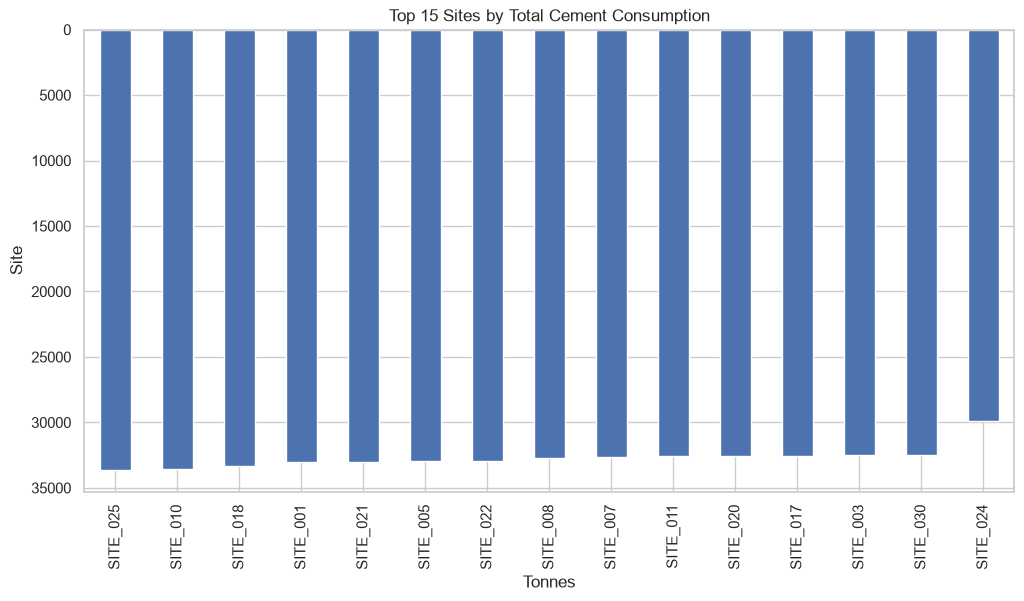

In [36]:
plt.figure(figsize=(12,6))
site_consumption.head(15).plot(kind='bar')  
plt.title("Top 15 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")   # was ylabel before
plt.ylabel("Site")     # was the index before
plt.gca().invert_yaxis() # optional: puts the highest value at the top
plt.show()


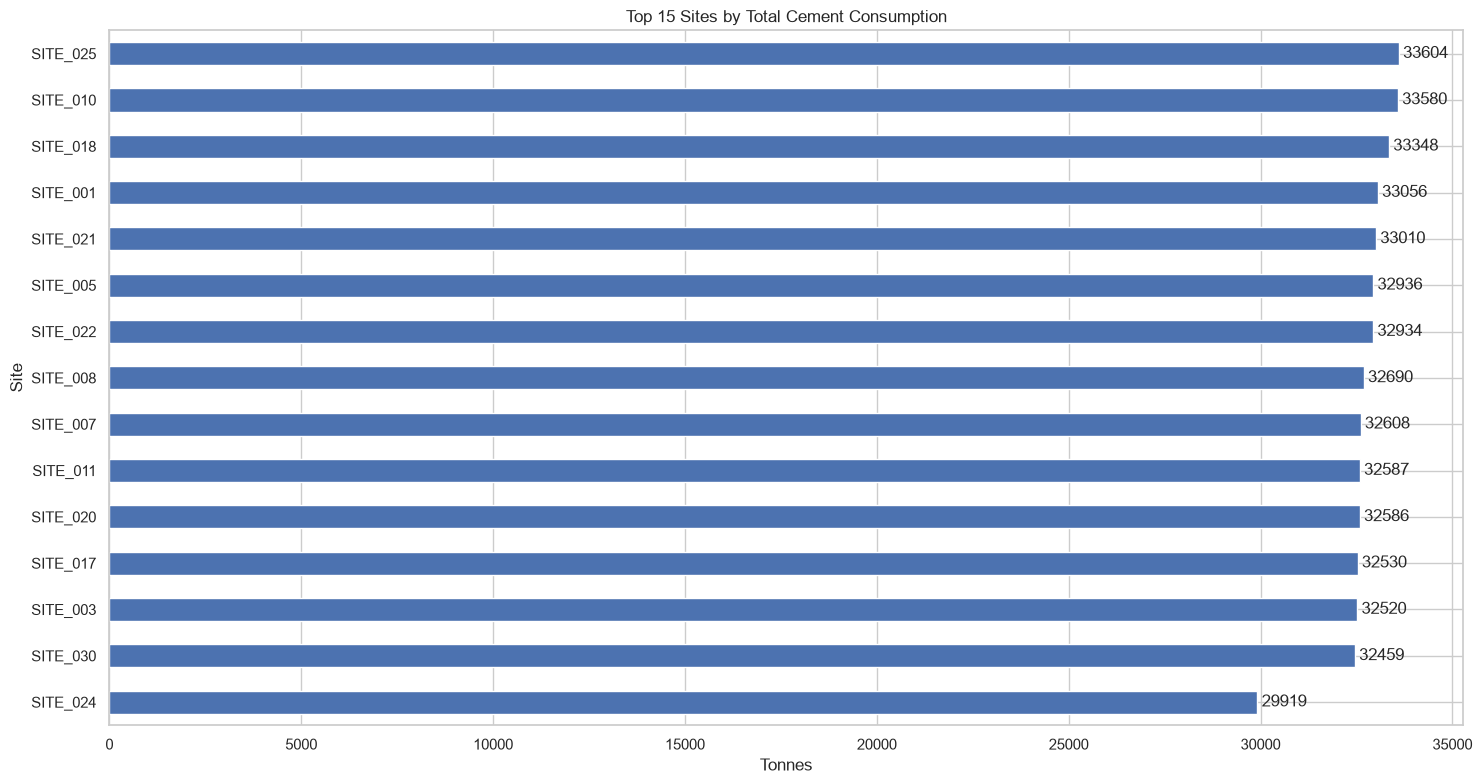

In [ ]:
plt.figure(figsize=(15,8))
ax = site_consumption.head(15).plot(kind='barh')
plt.title("Top 15 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")
plt.ylabel("Site")
ax.invert_yaxis() # biggest on top
# Add the values at the end of each bar
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3)
# fmt='%.0f' = no decimals. Use '%.1f' if you want 1 decimal
# padding=3 = space between bar end and text
plt.tight_layout()
plt.show()

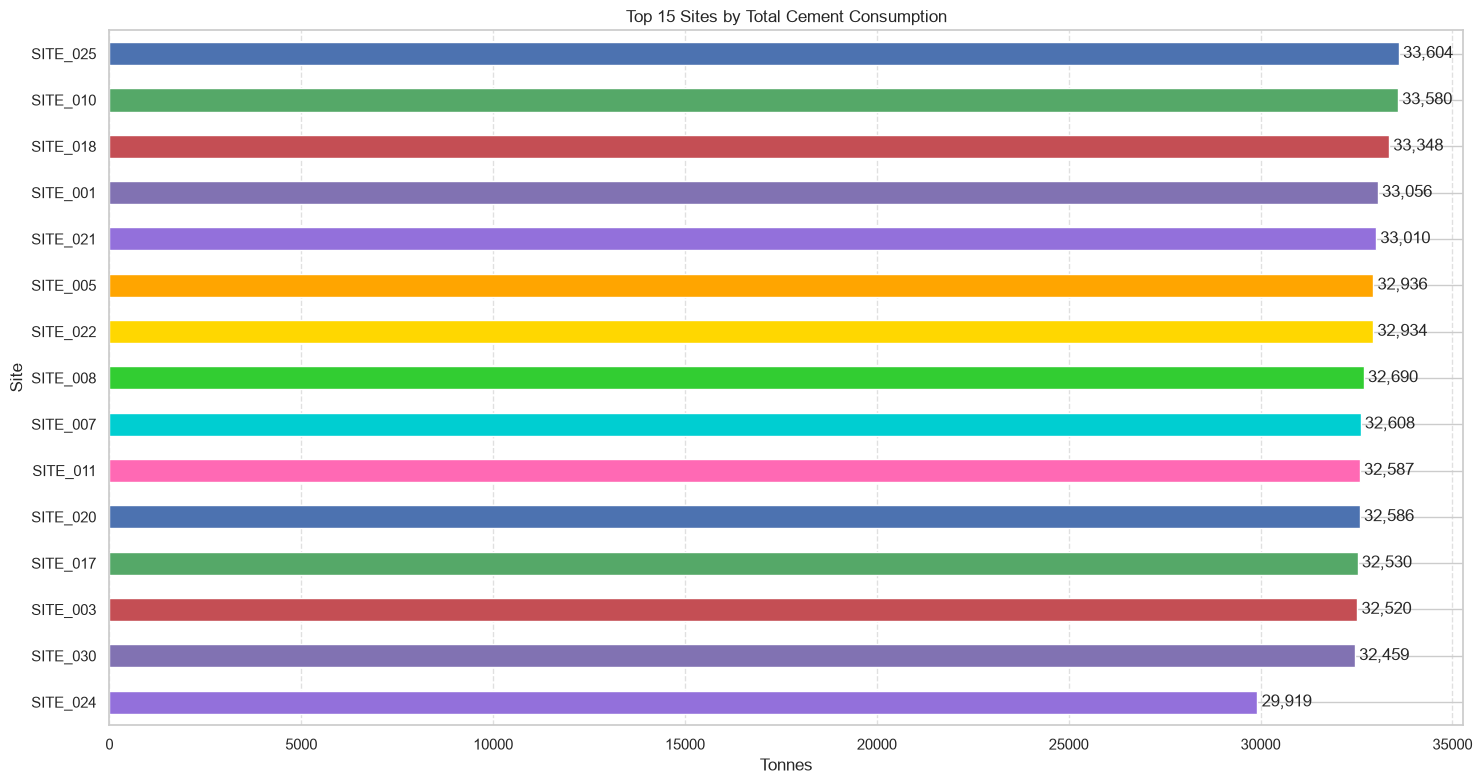

In [37]:
plt.figure(figsize=(15,8))
ax = site_consumption.head(15).plot(
    kind='barh',
    color=['#4C72B0','#55A868','#C44E54','#8172B2','#9370DB','#FFA500','#FFD700','#32CD32','#00CED1','#FF69B4'] # list of 15 colors, one per bar
)

plt.title("Top 15 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")
plt.ylabel("Site")

ax.invert_yaxis() # biggest on top

# Add grid lines only on x-axis for easier reading
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Add the values at the end of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3) # {:,.0f} adds commas: 1,245

plt.tight_layout()
plt.show()

### Insight: A small cluster of sites drives the majority of cement consumption. These sites should be prioritised for forecasting accuracy, inventory planning, and operational monitoring.

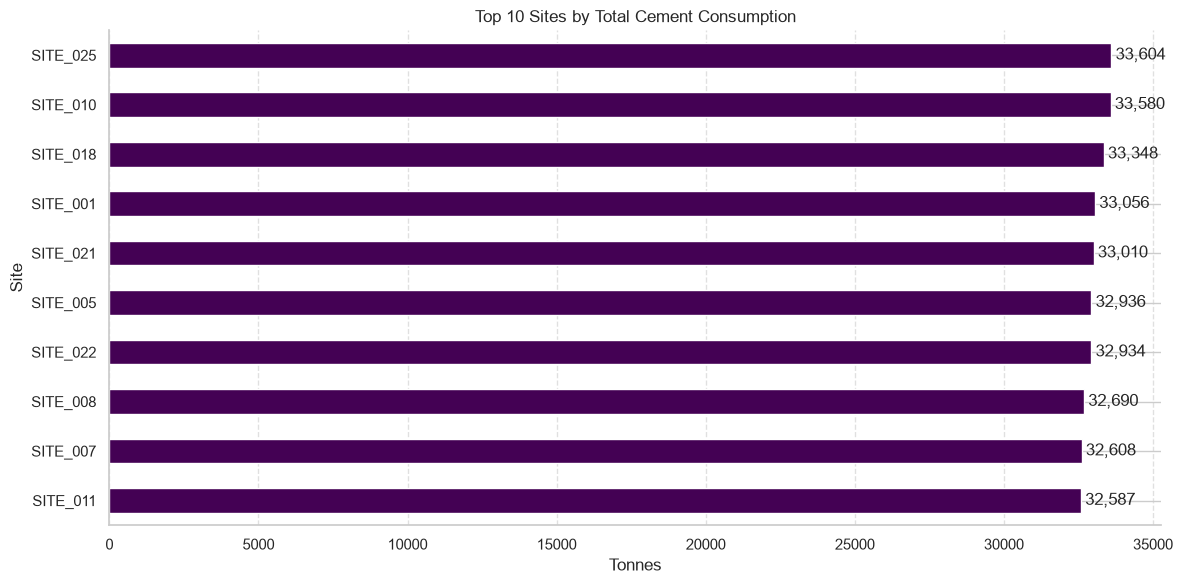

In [38]:
plt.figure(figsize=(12,6))
ax = site_consumption.head(10).plot(
    kind='barh',
    cmap='viridis' # gradient color map
)

plt.title("Top 10 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")
plt.ylabel("Site")

ax.invert_yaxis() # biggest on top

# Add grid lines only on x-axis for easier reading
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Add the values at the end of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3) # {:,.0f} adds commas: 1,245

ax.spines['top'].set_visible(False) # remove top border
ax.spines['right'].set_visible(False) # remove right border

plt.tight_layout()
plt.show()

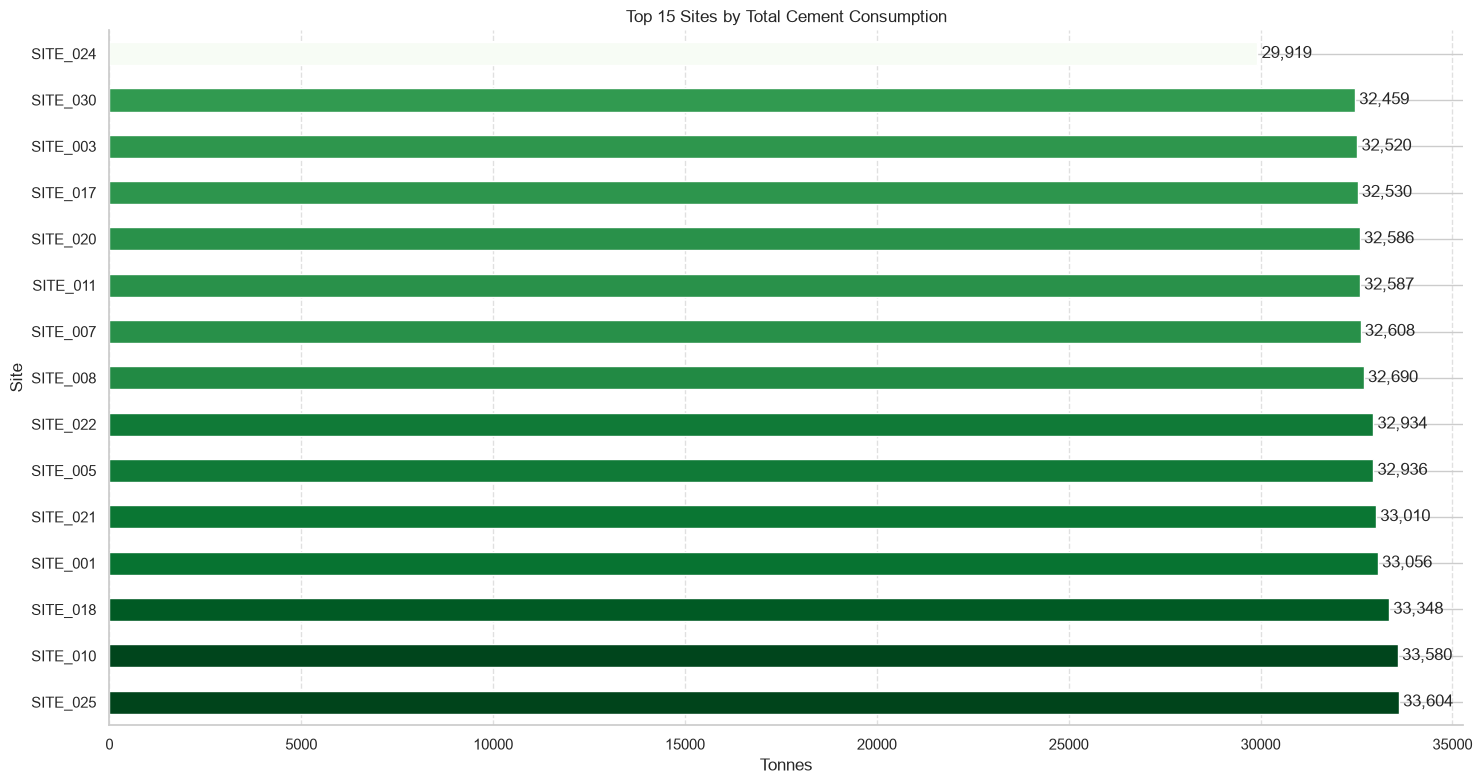

In [39]:
plt.figure(figsize=(15,8))

# 1. Get top 15 and sort biggest to smallest
data = site_consumption.head(15).sort_values(ascending=True) # ascending=True so biggest ends up on top after invert

# 2. Create a color gradient based on values
norm = plt.Normalize(data.min(), data.max()) # scale values to 0-1
colors = plt.cm.Greens(norm(data)) # Greens colormap. Darkest = highest value
# Other options: 'Reds', 'Greens', 'viridis', 'plasma'

# 3. Plot
ax = data.plot(kind='barh', color=colors)

plt.title("Top 15 Sites by Total Cement Consumption")
plt.xlabel("Tonnes")
plt.ylabel("Site")

ax.invert_yaxis() # biggest on top

# 4. Grid + labels
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3)

# Clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Region‑level consumption

In [40]:
region_consumption = df.groupby("region")["consumed_tonnes"].sum()
region_consumption

region
East     318968.12
North     57852.18
South    294887.83
West     108221.08
Name: consumed_tonnes, dtype: float64

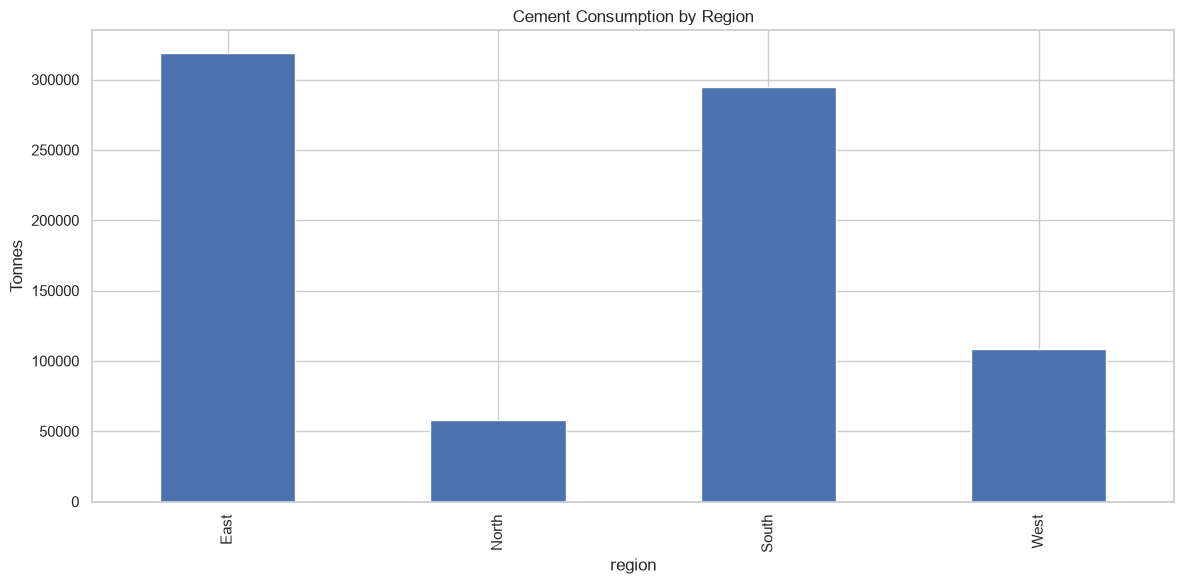

In [ ]:
region_consumption.plot(kind='bar', figsize=(12,6))
plt.title("Cement Consumption by Region")
plt.ylabel("Tonnes")
# Clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


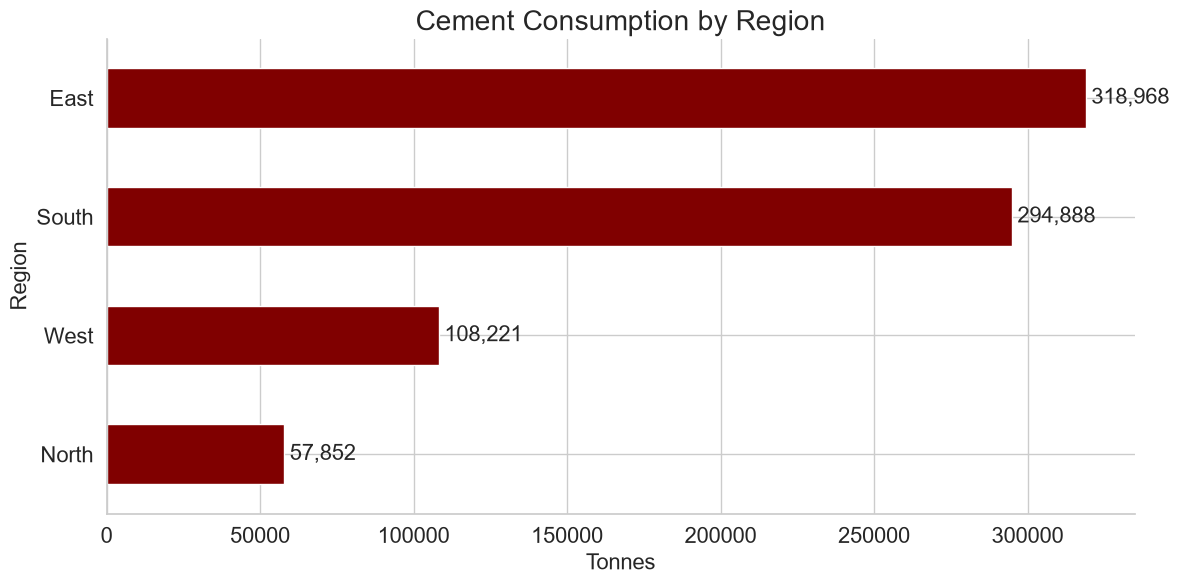

In [41]:
data = region_consumption.sort_values(ascending=False)

ax = data.plot(kind='barh', figsize=(12,6), color='maroon') # <- barh for horizontal

plt.title("Cement Consumption by Region", fontsize=20) # bigger title
plt.xlabel("Tonnes", fontsize=16)   # was ylabel for vertical bars
plt.ylabel("Region", fontsize=16)   # was index before

# Make tick labels bigger too
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.invert_yaxis() # optional: puts the biggest region on top

# Add value labels at the end of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=4, fontsize=16)
plt.tight_layout()
plt.show()

### Insight: The EAST region is the operational hotspot. This region should receive priority in logistics planning, silo capacity management, and forecasting accuracy.

##### Cement Type EDA

In [42]:
cement_type_usage = df.groupby("cement_type")["consumed_tonnes"].sum()
cement_type_usage

cement_type
CEM_I      259954.71
CEM_II     263418.26
CEM_III    256556.24
Name: consumed_tonnes, dtype: float64

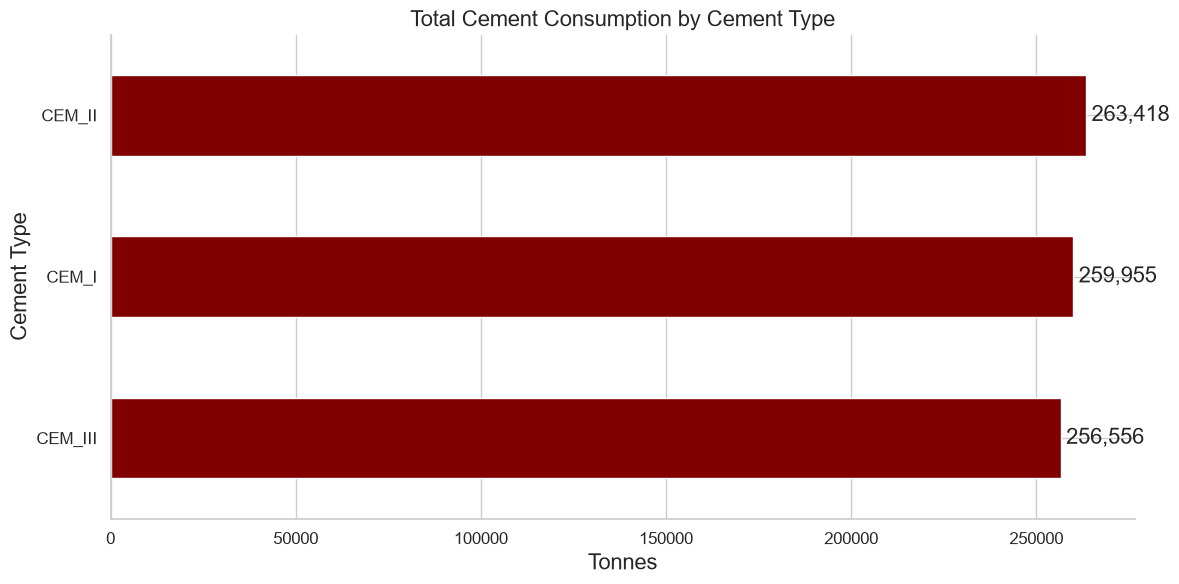

In [43]:
data = cement_type_usage.sort_values(ascending=False)
ax = data.plot(kind='barh', figsize=(12,6), color='maroon')
plt.title("Total Cement Consumption by Cement Type", fontsize=16)
plt.xlabel("Tonnes", fontsize=16)
plt.ylabel("Cement Type", fontsize=16)

# Make tick labels bigger too
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.invert_yaxis() # optional: puts the biggest cement type on top

ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=4, fontsize=16) # add value labels

# Clean up borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


###### Insight = CEM_II has the hightest consumption rate with a total of 263418.26 consumed tonnes. This makes it the dominant cement type across the business. This has implications for procurement, supplier contracts, and silo allocation.

##### Weather Impact EDA

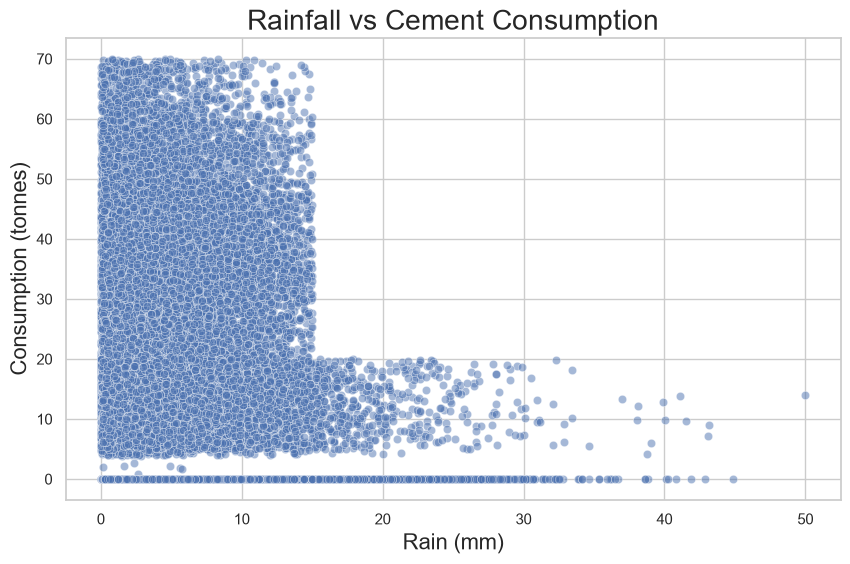

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['rain_mm'], y=df['consumed_tonnes'], alpha=0.5)
plt.title("Rainfall vs Cement Consumption", fontsize=20)
plt.xlabel("Rain (mm)", fontsize=16)
plt.ylabel("Consumption (tonnes)", fontsize=16)
# Clean up borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()


##### Insight:Light negative relationship — heavy rain slightly reduces consumption.

### Temperature vs Consumption

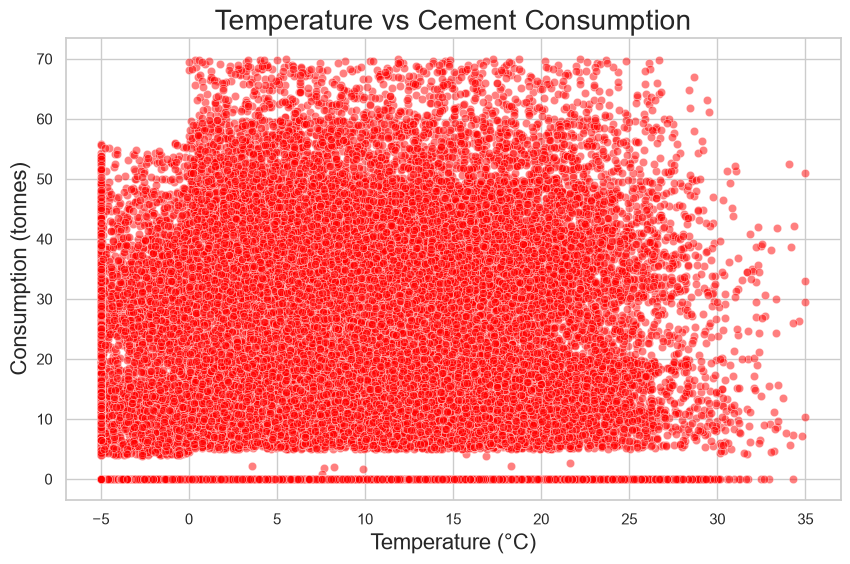

In [45]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['avg_temp_c'], y=df['consumed_tonnes'], alpha=0.5, color='red')
plt.title("Temperature vs Cement Consumption", fontsize=20)
plt.xlabel("Temperature (°C)", fontsize=16)
plt.ylabel("Consumption (tonnes)", fontsize=16)
plt.show()


### Insight : Weak positive relationship — warmer days slightly increase consumption

### Weather Insight: Weather influences pour activity. Rain reduces consumption slightly, while warmer temperatures support higher pour volumes. Weather should be included as a secondary forecasting feature.

##### Inventory levels over time

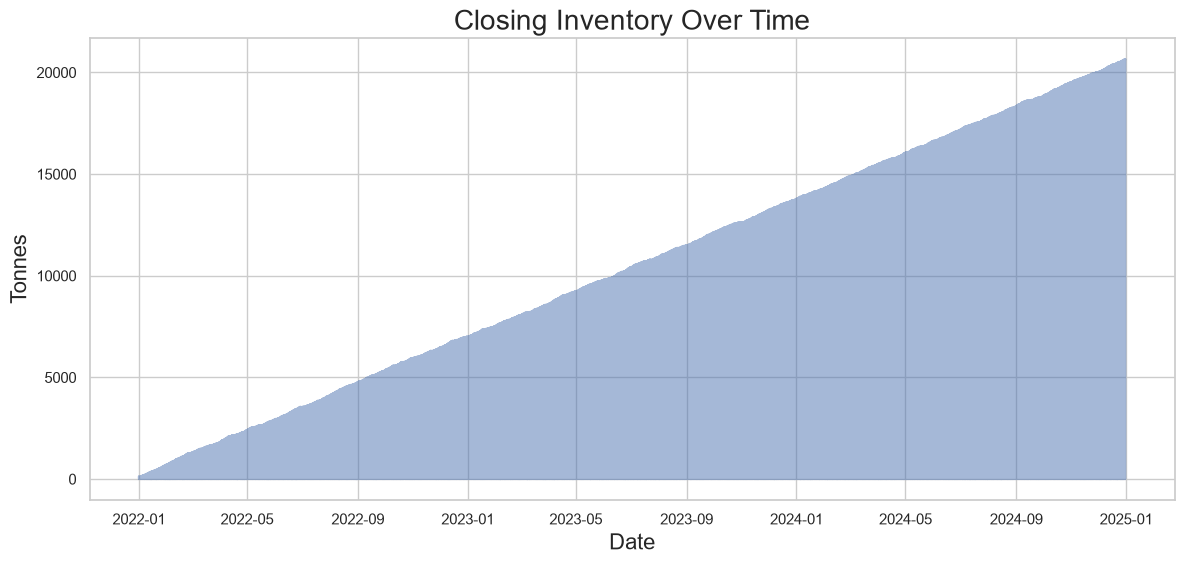

In [47]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['closing_inventory_tonnes'], alpha=0.5)
plt.title("Closing Inventory Over Time", fontsize=20)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Tonnes", fontsize=16)
plt.show()


##### Insight: Inventory levels have steadlity increased over the years. This is likely due to increased site activity or improved delivery scheduling.This supports the structural growth seen in yearly consumption. 

### Inventory turnover

In [48]:
df['inventory_turnover'] = df['consumed_tonnes'] / (df['opening_inventory_tonnes'] + 1)

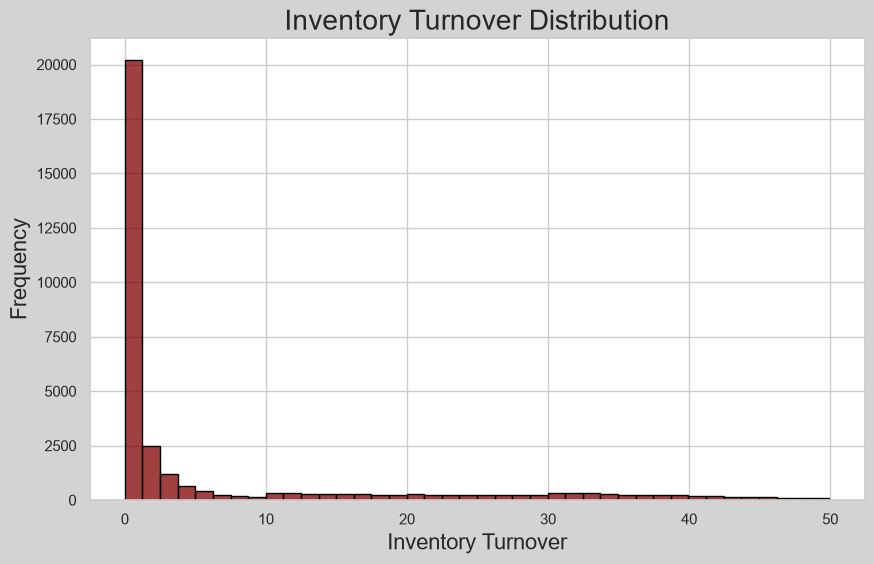

In [49]:
plt.figure(figsize=(10,6), facecolor='lightgray')
sns.histplot(df['inventory_turnover'], bins=40, color='maroon', edgecolor='black')
plt.title("Inventory Turnover Distribution", fontsize=20)
plt.xlabel("Inventory Turnover", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.show()

##### Insight: Turnover distribution shows most sites operate within a stable efficiency band.  Inventory turnover is stable across sites, indicating consistent operational behaviour. Outliers should be investigated for inefficiencies or exceptional site conditions.

### Correlation Heatmap

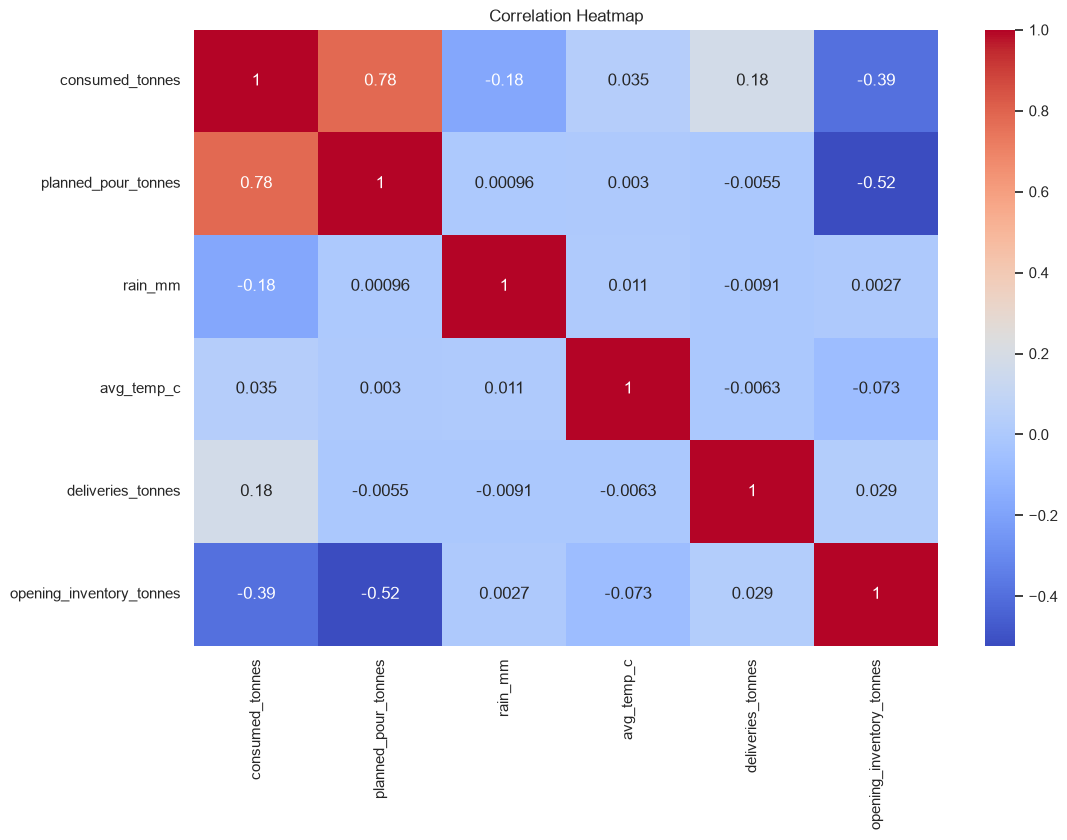

In [50]:
plt.figure(figsize=(12,8))
sns.heatmap(df[['consumed_tonnes','planned_pour_tonnes','rain_mm','avg_temp_c','deliveries_tonnes','opening_inventory_tonnes']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


###### Insight: There is a strong correlation between Planned pours and consumed tonnes, Deliveries  and opening inventory. Temperature has a slight positive correlation while Rain is a slight negative correlation. Consumption is strongly driven by planned pours — confirming operational discipline.Weather plays a secondary role. Deliveries and inventory behave as expected.

In [51]:
site_consumption.to_csv("site_consumption_summary.csv")
cement_type_usage.to_csv("cement_type_usage_summary.csv")


C:\Users\akand\AppData\Local\Temp\ipykernel_2692\725882126.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['consumed_tonnes'].resample('M').sum()
C:\Users\akand\AppData\Local\Temp\ipykernel_2692\725882126.py:11: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df['consumed_tonnes'].resample('Q').sum()
C:\Users\akand\AppData\Local\Temp\ipykernel_2692\725882126.py:12: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['consumed_tonnes'].resample('Y').sum()


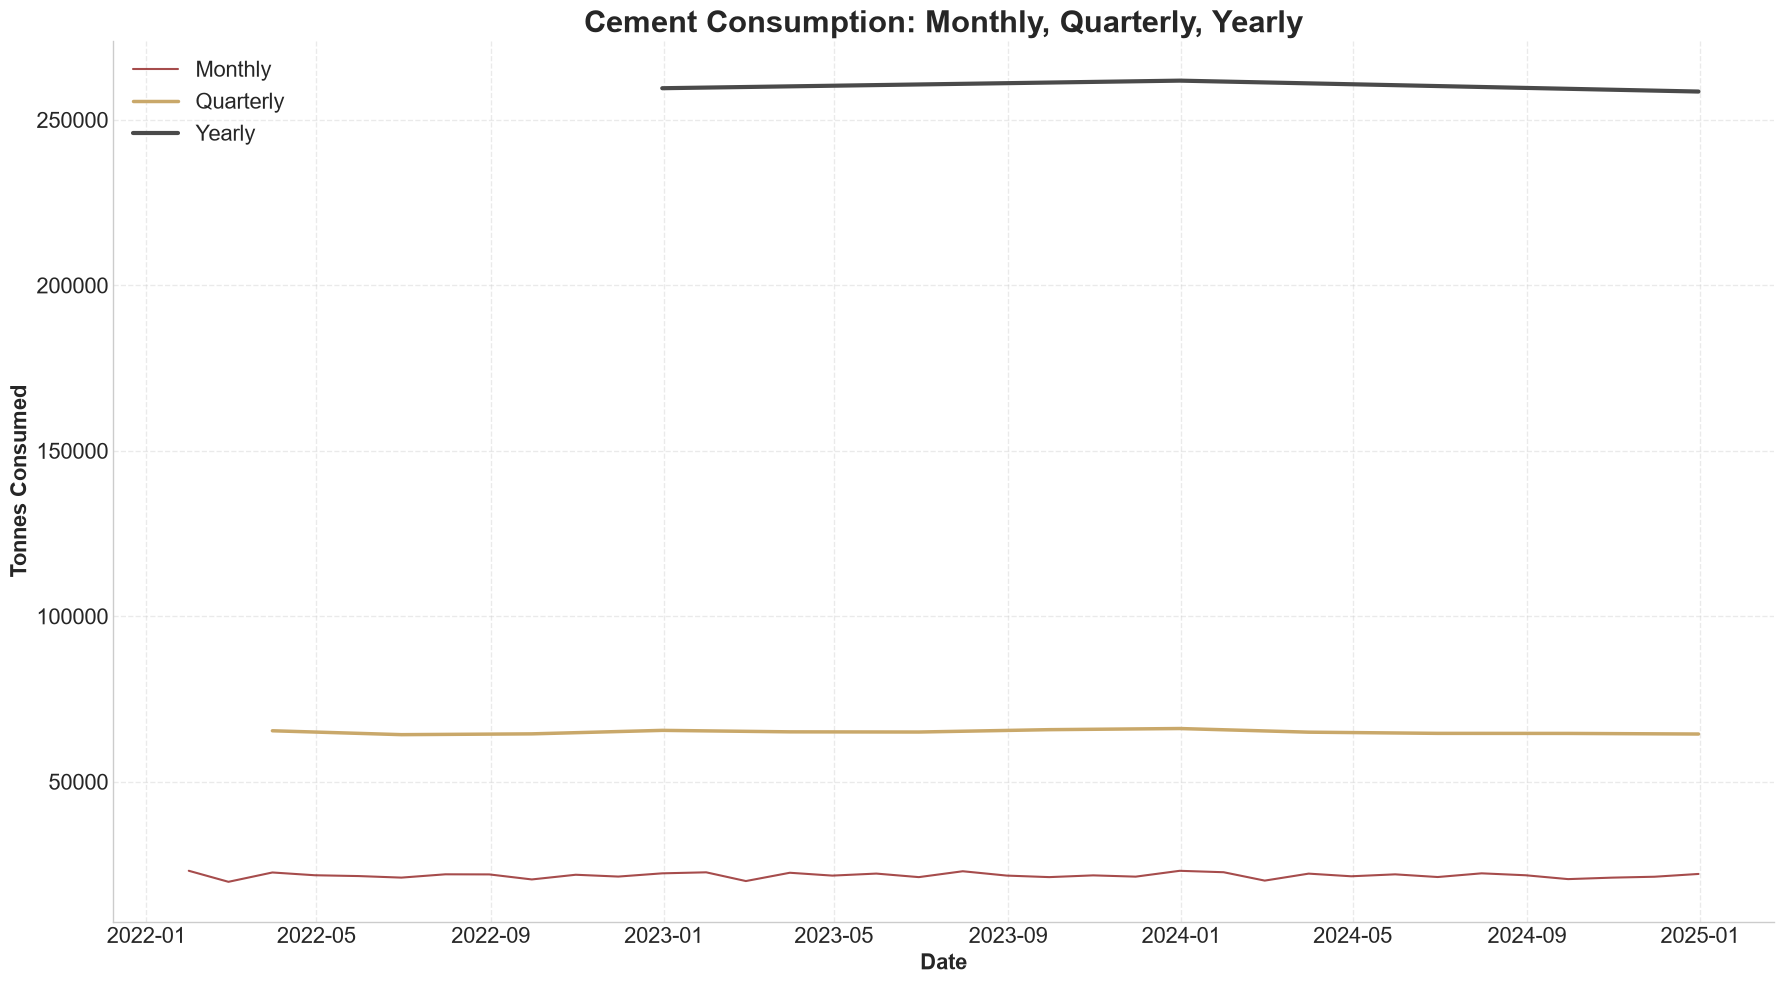

In [59]:
# Presentation colour palette
maroon = "#800000"
gold = "#C9A86A"
navy = "#0A1A44"
teal = "#1B7F7A"
grey = "#4A4A4A"
light_grey = "#D9D9D9"


monthly = df['consumed_tonnes'].resample('M').sum()
quarterly = df['consumed_tonnes'].resample('Q').sum()
yearly = df['consumed_tonnes'].resample('Y').sum()

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(18,10), facecolor="none")

ax.plot(monthly.index, monthly.values, label="Monthly", color=maroon, alpha=0.7)
ax.plot(quarterly.index, quarterly.values, label="Quarterly", color=gold, linewidth=2.5)
ax.plot(yearly.index, yearly.values, label="Yearly", color=grey, linewidth=3)

ax.set_title("Cement Consumption: Monthly, Quarterly, Yearly", fontsize=22, fontweight="bold")
ax.set_xlabel("Date", fontsize=16, fontweight="bold")
ax.set_ylabel("Tonnes Consumed", fontsize=16, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=16)

# Make tick labels bigger too
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Clean up borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


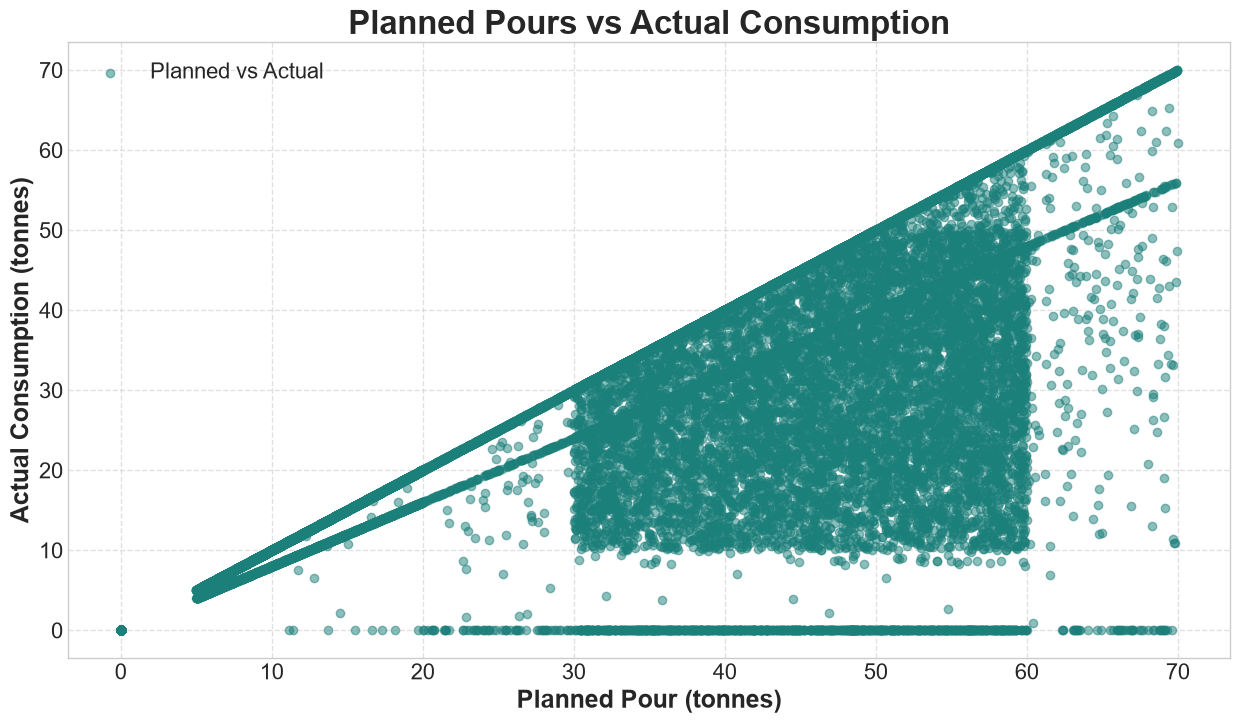

In [89]:
plt.figure(figsize=(15,8), facecolor="none")

plt.scatter(df['planned_pour_tonnes'], df['consumed_tonnes'], 
            alpha=0.5, color=teal, label="Planned vs Actual")

plt.title("Planned Pours vs Actual Consumption", fontsize=24, fontweight="bold")
plt.xlabel("Planned Pour (tonnes)", fontsize=18, fontweight="bold")
plt.ylabel("Actual Consumption (tonnes)", fontsize=18, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=16, frameon=False)

plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)

plt.show()


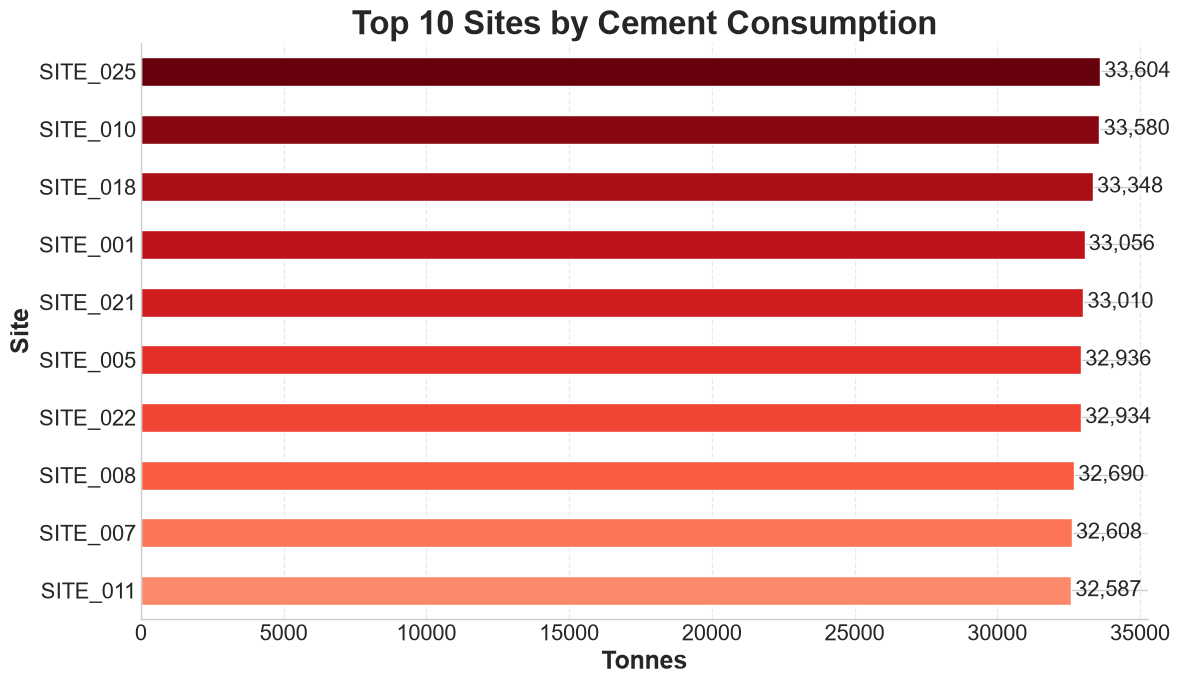

In [67]:
site_totals = df.groupby("site_id")["consumed_tonnes"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,7), facecolor="none")
colors = plt.cm.Reds(np.linspace(0.4, 1, 10))

ax = site_totals.sort_values().plot(kind='barh', color=colors)

ax.set_title("Top 10 Sites by Cement Consumption", fontsize=24, fontweight="bold")
ax.set_xlabel("Tonnes", fontsize=18, fontweight="bold")
ax.set_ylabel("Site", fontsize=18, fontweight="bold")

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3, fontsize=16)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


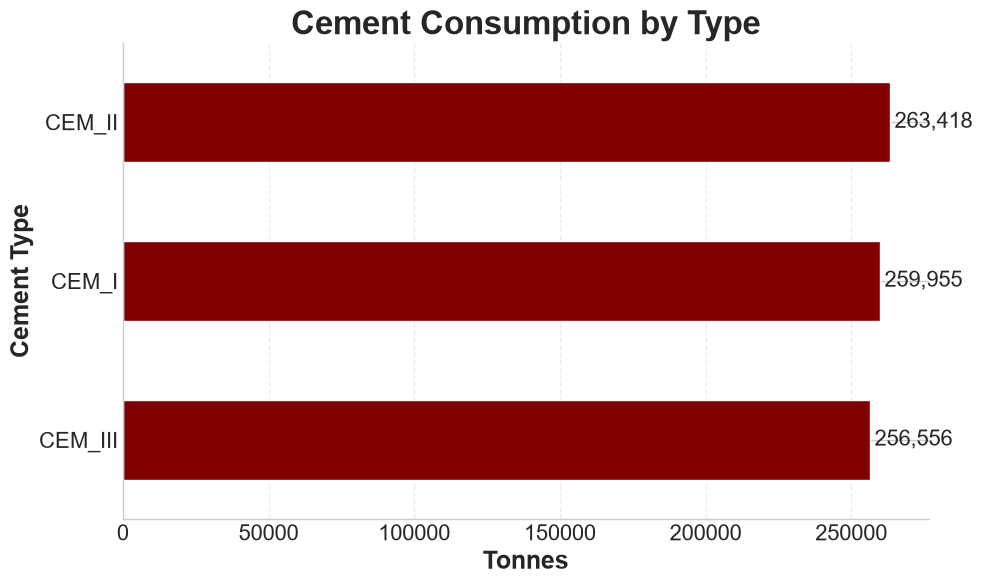

In [62]:
cement_usage = df.groupby("cement_type")["consumed_tonnes"].sum().sort_values()

plt.figure(figsize=(10,6), facecolor="none")
ax = cement_usage.plot(kind='barh', color=maroon)

ax.set_title("Cement Consumption by Type", fontsize=24, fontweight="bold")
ax.set_xlabel("Tonnes", fontsize=18, fontweight="bold")
ax.set_ylabel("Cement Type", fontsize=18, fontweight="bold")

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3, fontsize=16)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


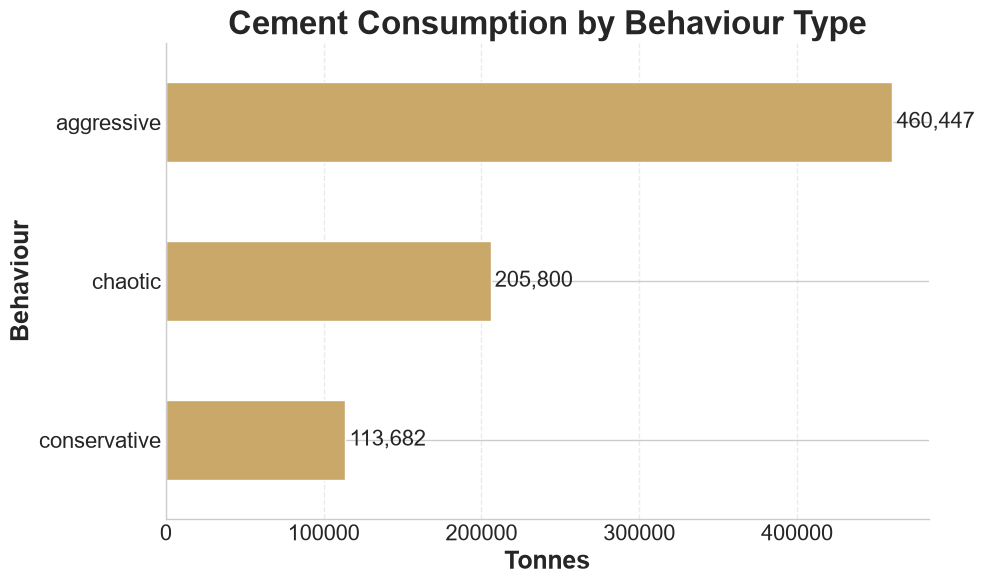

In [63]:
behaviour_usage = df.groupby("behavior")["consumed_tonnes"].sum().sort_values()

plt.figure(figsize=(10,6), facecolor="none")
ax = behaviour_usage.plot(kind='barh', color=gold)

ax.set_title("Cement Consumption by Behaviour Type", fontsize=24, fontweight="bold")
ax.set_xlabel("Tonnes", fontsize=18, fontweight="bold")
ax.set_ylabel("Behaviour", fontsize=18, fontweight="bold")

ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=3, fontsize=16)

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


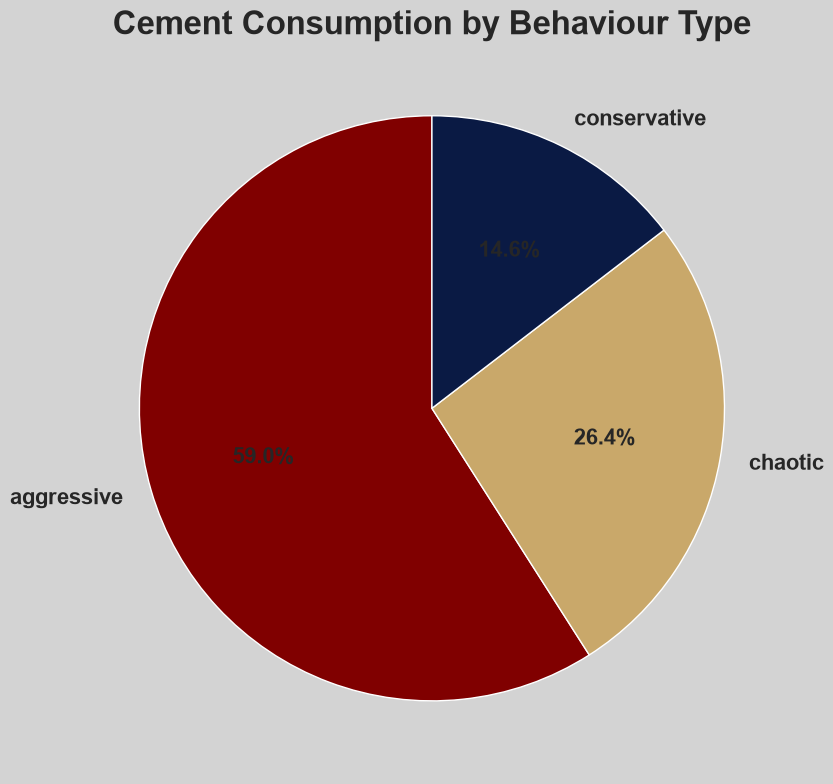

In [68]:
# Aggregate behaviour totals
behaviour_usage = df.groupby("behavior")["consumed_tonnes"].sum()

# Custom colour palette for pie chart
colors = [maroon, gold, navy, teal]  # adjust depending on number of behaviours

plt.figure(figsize=(10,8), facecolor="lightgray")

behaviour_usage.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize":16, "fontweight":"bold"},
    wedgeprops={"linewidth":1, "edgecolor":"white"}
)

plt.title("Cement Consumption by Behaviour Type", fontsize=24, fontweight="bold")
plt.ylabel("")  # removes the default y-label for cleaner look

plt.tight_layout()
plt.show()


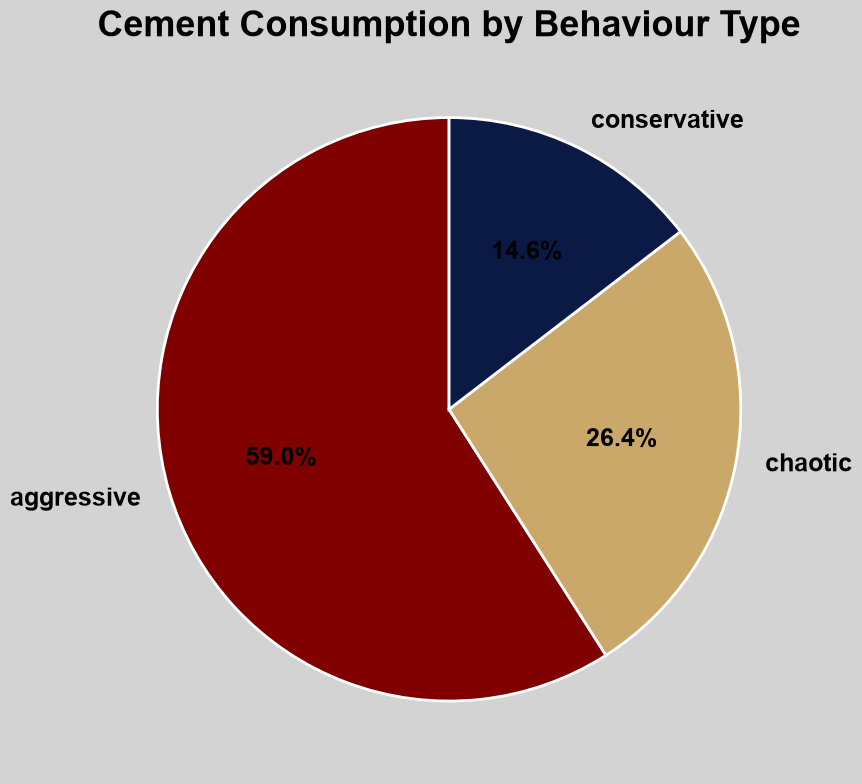

In [73]:

# Aggregate behaviour totals
behaviour_usage = df.groupby("behavior")["consumed_tonnes"].sum()

# Custom colour palette for pie chart
colors = [maroon, gold, navy, teal]  # adjust depending on number of behaviours

plt.figure(figsize=(10,8), facecolor="lightgray")

behaviour_usage.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize":18, "fontweight":"bold", "color":"black"},
    wedgeprops={"linewidth":2, "edgecolor":"white"}
)

plt.title("Cement Consumption by Behaviour Type", fontsize=26, fontweight="bold", color="black")
plt.ylabel("")  # removes default y-label for cleaner look

plt.tight_layout()
plt.show()


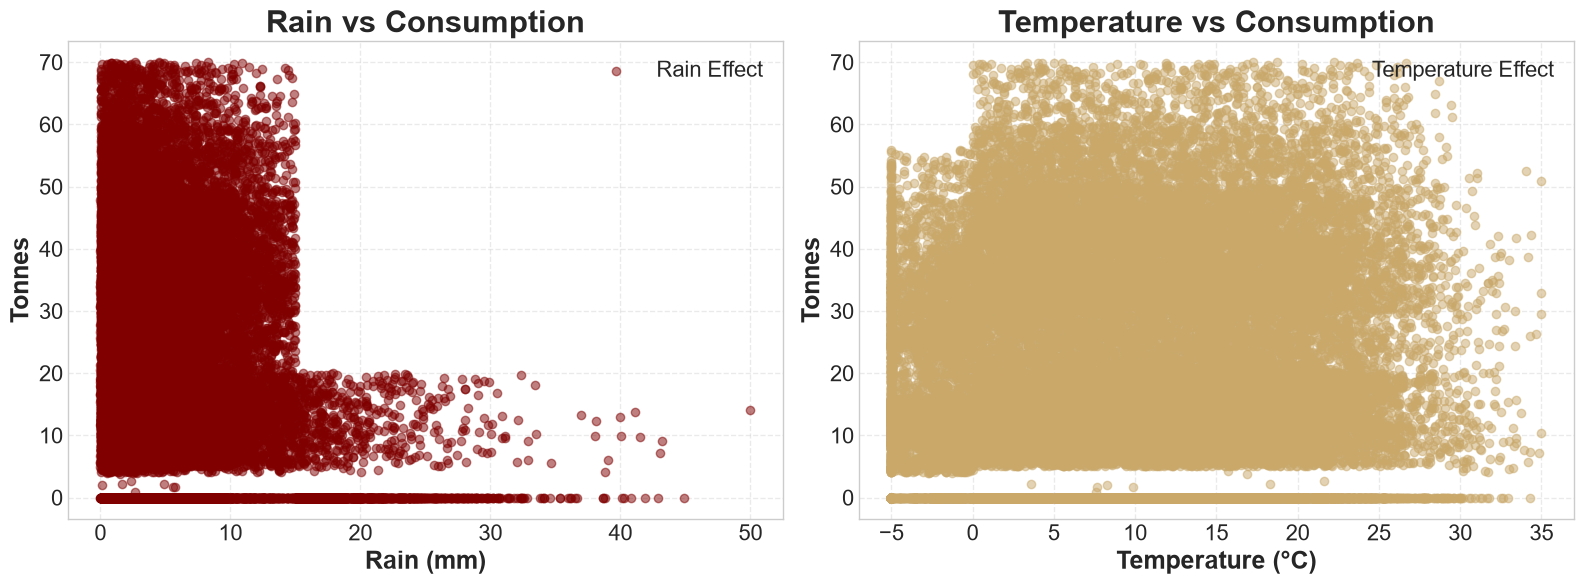

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16,6), facecolor="none")

axes[0].scatter(df['rain_mm'], df['consumed_tonnes'], alpha=0.5, color=maroon, label="Rain Effect")
axes[0].set_title("Rain vs Consumption", fontsize=22, fontweight="bold")
axes[0].set_xlabel("Rain (mm)", fontsize=18, fontweight="bold")
axes[0].set_ylabel("Tonnes", fontsize=18, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.4)
axes[0].legend(fontsize=16, frameon=False)
axes[0].tick_params(axis='x', labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)

axes[1].scatter(df['avg_temp_c'], df['consumed_tonnes'], alpha=0.5, color=gold, label="Temperature Effect")
axes[1].set_title("Temperature vs Consumption", fontsize=22, fontweight="bold")
axes[1].set_xlabel("Temperature (°C)", fontsize=18, fontweight="bold")
axes[1].set_ylabel("Tonnes", fontsize=18, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.4)
axes[1].legend(fontsize=16, frameon=False)
axes[1].tick_params(axis='x', labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()


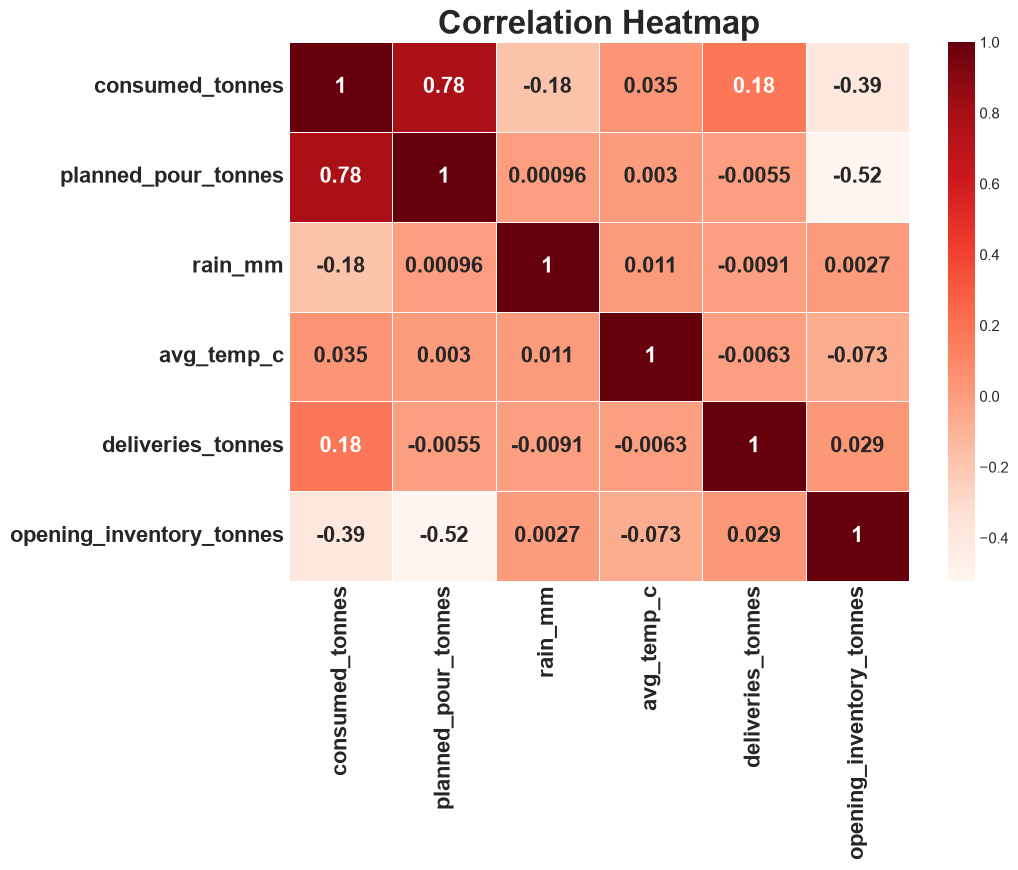

In [75]:
import seaborn as sns

plt.figure(figsize=(10,7), facecolor="none")

sns.heatmap(
    df[['consumed_tonnes','planned_pour_tonnes','rain_mm','avg_temp_c',
        'deliveries_tonnes','opening_inventory_tonnes']].corr(),
    annot=True,
    cmap="Reds",
    linewidths=0.5,
    annot_kws={"size":16, "fontweight":"bold"}
)

plt.title("Correlation Heatmap", fontsize=24, fontweight="bold")
plt.xticks(fontsize=16, fontweight="bold")
plt.yticks(fontsize=16, fontweight="bold")

plt.show()


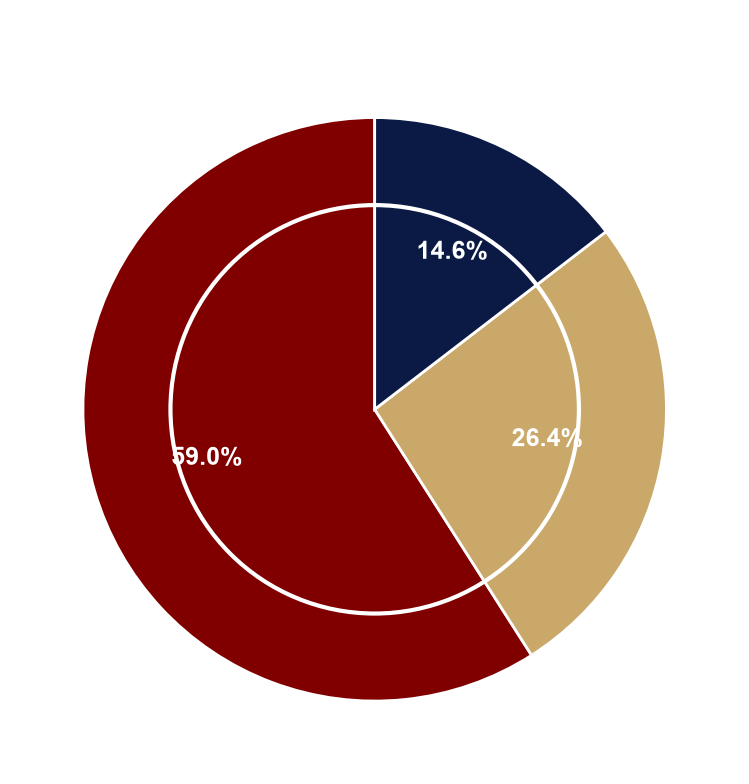

In [76]:
# Aggregate behaviour totals
behaviour_usage = df.groupby("behavior")["consumed_tonnes"].sum()

# Custom colour palette for donut chart
colors = [maroon, gold, navy, teal]  # adjust depending on number of behaviours

plt.figure(figsize=(10,8), facecolor="none")

# Create pie chart
wedges, texts, autotexts = plt.pie(
    behaviour_usage,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={"fontsize":18, "fontweight":"bold", "color":"white"},
    wedgeprops={"linewidth":2, "edgecolor":"white"}
)

# Draw a white circle in the middle to create the donut effect
centre_circle = plt.Circle((0,0), 0.70, fc='none', edgecolor='white', linewidth=3)
plt.gca().add_artist(centre_circle)

# Title
plt.title("Cement Consumption by Behaviour Type", fontsize=26, fontweight="bold", color="white")

# Remove default y-label
plt.ylabel("")

plt.tight_layout()
plt.show()


### Check for ouliers

### Boxplot for consumed tonnes

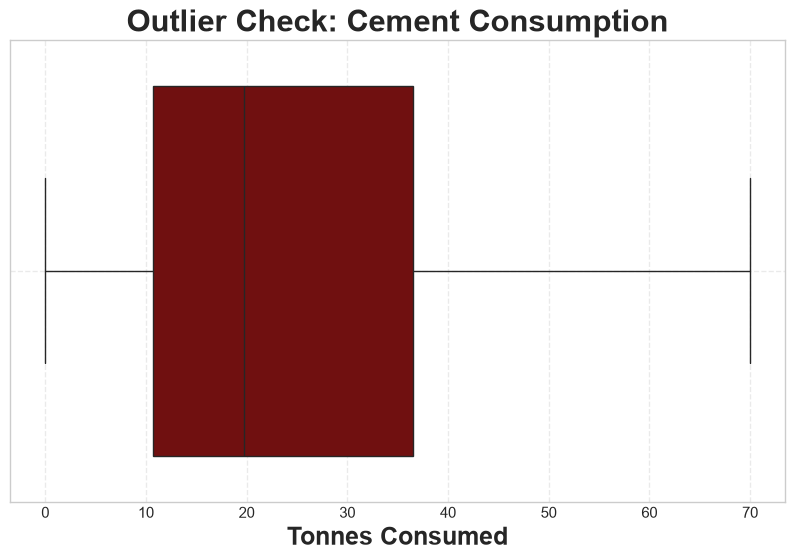

In [77]:
plt.figure(figsize=(10,6), facecolor="none")
sns.boxplot(x=df['consumed_tonnes'], color="#800000")
plt.title("Outlier Check: Cement Consumption", fontsize=22, fontweight="bold")
plt.xlabel("Tonnes Consumed", fontsize=18, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


### Time-series spike detection

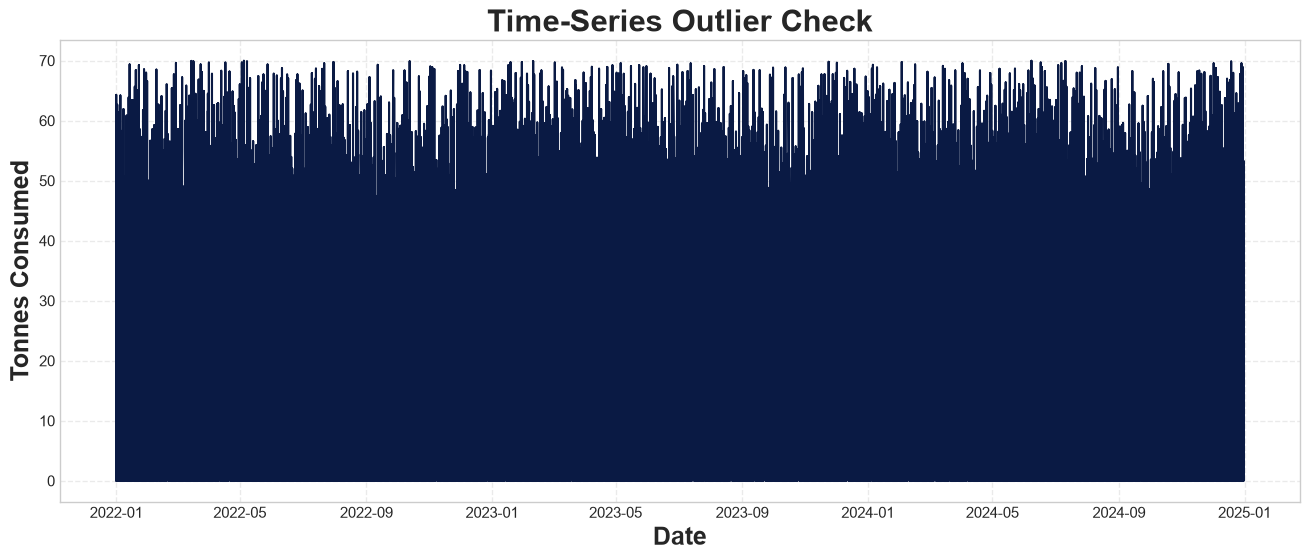

In [78]:
plt.figure(figsize=(16,6), facecolor="none")
plt.plot(df.index, df['consumed_tonnes'], color="#0A1A44")
plt.title("Time-Series Outlier Check", fontsize=22, fontweight="bold")
plt.xlabel("Date", fontsize=18, fontweight="bold")
plt.ylabel("Tonnes Consumed", fontsize=18, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


### STATISTICAL OUTLIER DETECTION - A. IQR Method (Industry Standard)

In [79]:
Q1 = df['consumed_tonnes'].quantile(0.25)
Q3 = df['consumed_tonnes'].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df[(df['consumed_tonnes'] < Q1 - 1.5*IQR) |
                  (df['consumed_tonnes'] > Q3 + 1.5*IQR)]

outliers_iqr.head()


,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,expected_closing,region,silo_capacity,behavior,inventory_turnover
date,,,,,,,,,,,,,,


### B. Z‑Score Method (Good for Normal-ish Data)

In [80]:
df['z_score'] = (df['consumed_tonnes'] - df['consumed_tonnes'].mean()) / df['consumed_tonnes'].std()

outliers_z = df[df['z_score'].abs() > 3]
outliers_z.head()


,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,expected_closing,region,silo_capacity,behavior,inventory_turnover,z_score
date,,,,,,,,,,,,,,,


### SITE‑LEVEL OUTLIER DETECTION - This is critical because each site behaves differently.

In [81]:
site_outliers = df.groupby('site_id').apply(
    lambda x: x[(x['consumed_tonnes'] > x['consumed_tonnes'].mean() + 3*x['consumed_tonnes'].std()) |
               (x['consumed_tonnes'] < x['consumed_tonnes'].mean() - 3*x['consumed_tonnes'].std())]
)

site_outliers.head()


C:\Users\akand\AppData\Local\Temp\ipykernel_2692\1235163850.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  site_outliers = df.groupby('site_id').apply(


,,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,expected_closing,region,silo_capacity,behavior,inventory_turnover,z_score
site_id,date,,,,,,,,,,,,,,,


### WEATHER‑RELATED OUTLIERS

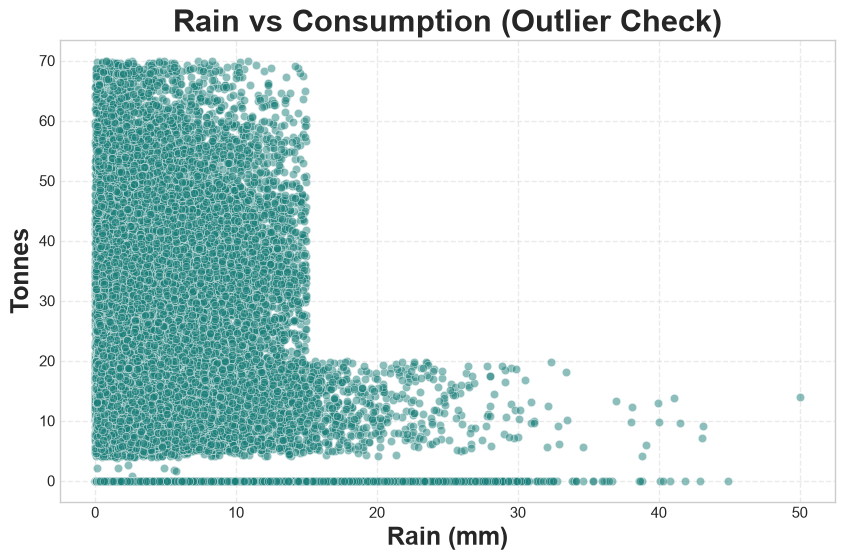

In [82]:
plt.figure(figsize=(10,6), facecolor="none")
sns.scatterplot(x=df['rain_mm'], y=df['consumed_tonnes'], color="#1B7F7A", alpha=0.5)
plt.title("Rain vs Consumption (Outlier Check)", fontsize=22, fontweight="bold")
plt.xlabel("Rain (mm)", fontsize=18, fontweight="bold")
plt.ylabel("Tonnes", fontsize=18, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


C:\Users\akand\AppData\Local\Temp\ipykernel_2692\1393280546.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['consumed_tonnes'].resample('M').sum()
C:\Users\akand\AppData\Local\Temp\ipykernel_2692\1393280546.py:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = df['consumed_tonnes'].resample('Q').sum()
C:\Users\akand\AppData\Local\Temp\ipykernel_2692\1393280546.py:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df['consumed_tonnes'].resample('Y').sum()


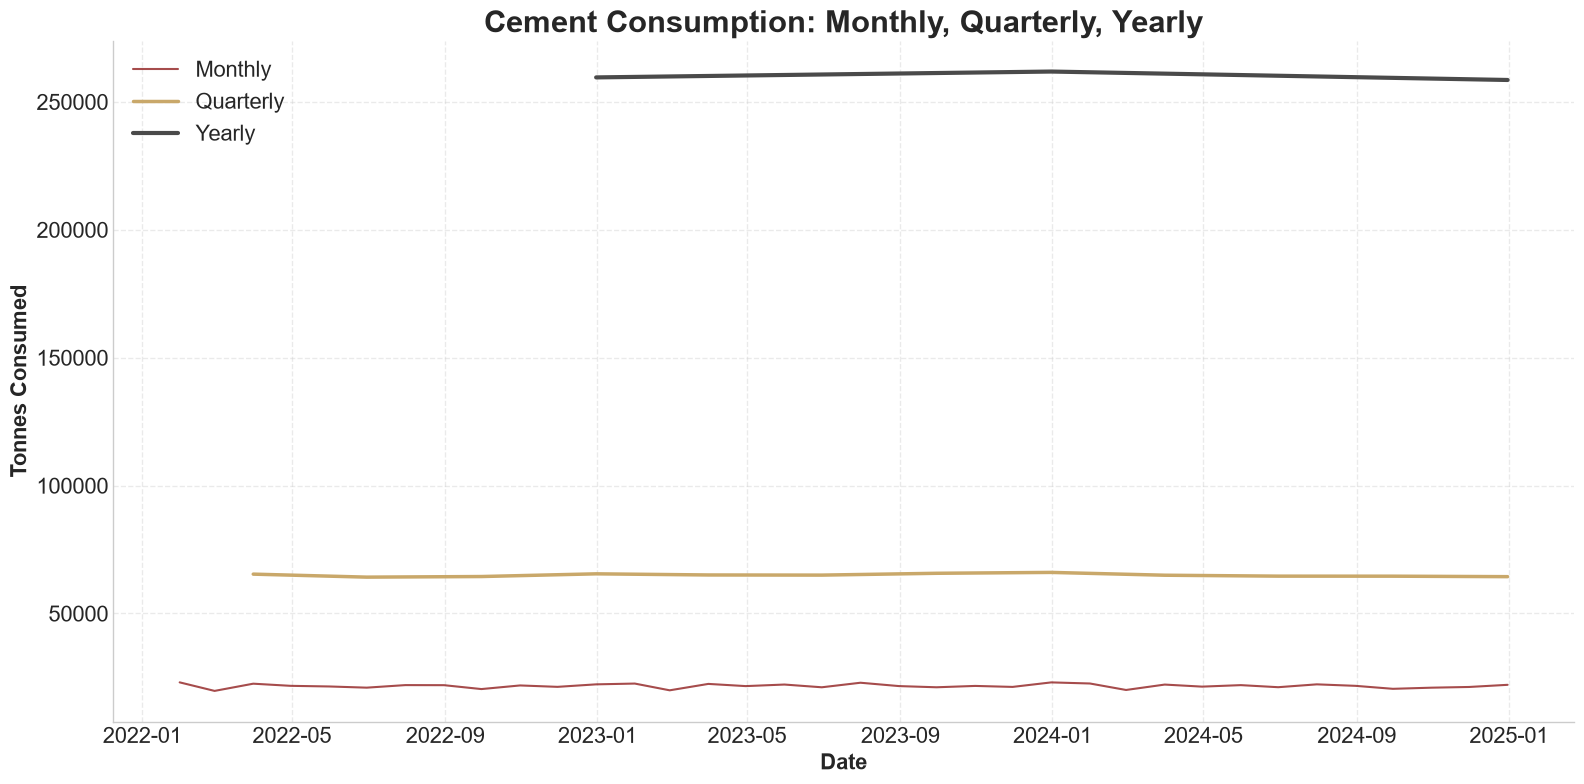

In [ ]:
maroon = "#800000"
gold = "#C9A86A"
grey = "#4A4A4A"

monthly = df['consumed_tonnes'].resample('M').sum()
quarterly = df['consumed_tonnes'].resample('Q').sum()
yearly = df['consumed_tonnes'].resample('Y').sum()

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(16,8), facecolor="none")

ax.plot(monthly.index, monthly.values, label="Monthly", color=maroon, alpha=0.7)
ax.plot(quarterly.index, quarterly.values, label="Quarterly", color=gold, linewidth=2.5)
ax.plot(yearly.index, yearly.values, label="Yearly", color=grey, linewidth=3)

ax.set_title("Cement Consumption: Monthly, Quarterly, Yearly", fontsize=22, fontweight="bold")
ax.set_xlabel("Date", fontsize=16, fontweight="bold")
ax.set_ylabel("Tonnes Consumed", fontsize=16, fontweight="bold")

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=16)

# Make tick labels bigger too
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Clean up borders
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


### OPERATIONAL OUTLIERS

In [83]:
zero_days = df[df['consumed_tonnes'] == 0]
zero_days.head()


,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,expected_closing,region,silo_capacity,behavior,inventory_turnover,z_score
date,,,,,,,,,,,,,,,
2022-01-01,SITE_014,CEM_I,0.00,0.0,41.51,21.18,62.69,1.93,12.87,62.69,West,230,chaotic,0.0,-1.408057
2022-01-01,SITE_005,CEM_II,42.42,0.0,79.21,46.97,126.18,29.77,23.52,126.18,South,230,aggressive,0.0,-1.408057
2022-01-02,SITE_007,CEM_III,0.00,0.0,20.53,20.41,40.94,0.85,6.16,40.94,East,485,aggressive,0.0,-1.408057
2022-01-02,SITE_026,CEM_II,0.00,0.0,41.66,43.38,85.04,4.31,13.48,85.04,South,369,chaotic,0.0,-1.408057
2022-01-02,SITE_021,CEM_III,0.00,0.0,36.88,10.05,46.93,3.34,2.92,46.93,East,180,aggressive,0.0,-1.408057


### Negative inventory adjustments

In [84]:
negative_inventory = df[df['closing_inventory_tonnes'] < 0]
negative_inventory.head()


,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,expected_closing,region,silo_capacity,behavior,inventory_turnover,z_score
date,,,,,,,,,,,,,,,


### Sudden inventory jumps

In [85]:
inventory_spikes = df[df['closing_inventory_tonnes'].diff().abs() > 100]
inventory_spikes.head()


,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,expected_closing,region,silo_capacity,behavior,inventory_turnover,z_score
date,,,,,,,,,,,,,,,
2022-01-01,SITE_008,CEM_III,48.63,48.63,20.33,30.38,2.08,6.33,2.46,2.08,West,260,aggressive,2.279887,1.478639
2022-01-03,SITE_027,CEM_II,14.00,14.00,93.59,37.89,117.48,2.80,16.46,117.48,North,314,conservative,0.148007,-0.577011
2022-01-04,SITE_020,CEM_I,32.75,32.75,29.76,44.11,41.12,0.79,11.10,41.12,South,363,aggressive,1.064694,0.535996
2022-01-04,SITE_009,CEM_I,10.93,10.93,109.18,36.52,134.77,2.70,6.71,134.77,East,352,conservative,0.099201,-0.759248
2022-01-05,SITE_020,CEM_II,47.43,47.43,41.12,31.12,24.81,2.68,13.94,24.81,South,363,aggressive,1.126068,1.407407


### Planned pours but no consumption

In [86]:
planned_no_actual = df[(df['planned_pour_tonnes'] > 0) & (df['consumed_tonnes'] == 0)]
planned_no_actual.head()


,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,expected_closing,region,silo_capacity,behavior,inventory_turnover,z_score
date,,,,,,,,,,,,,,,
2022-01-01,SITE_005,CEM_II,42.42,0.0,79.21,46.97,126.18,29.77,23.52,126.18,South,230,aggressive,0.0,-1.408057
2022-01-04,SITE_025,CEM_I,35.89,0.0,2.00,22.89,24.89,23.79,11.17,24.89,South,261,aggressive,0.0,-1.408057
2022-01-08,SITE_013,CEM_II,46.40,0.0,34.63,0.00,34.63,16.66,8.74,34.63,South,154,chaotic,0.0,-1.408057
2022-01-12,SITE_018,CEM_III,53.60,0.0,0.00,20.57,20.57,25.54,6.16,20.57,East,152,aggressive,0.0,-1.408057
2022-01-13,SITE_007,CEM_I,53.75,0.0,2.51,37.96,40.47,15.31,5.37,40.47,East,485,aggressive,0.0,-1.408057


In [90]:
df.to_csv("MIG_clean.csv")


In [4]:
import pandas as pd

df = pd.read_csv("../data/MIG_clean.csv", parse_dates=["date"])


In [5]:
df['behavior'].unique()


array(['aggressive', 'chaotic', 'conservative'], dtype=object)

In [6]:
df.to_csv("MIG_clean.csv")